### Download single cell sequencing data: home_cage_umi_counts.csv and home_cage_metadata.csv
from https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE173947

In [1]:
import numpy as np
fl = r'C:\Users\duble\Dropbox\code_Seurat\OR_MERFISH_2020\PostProcess\home_cage_umi_counts.csv'
lines = [ln[:-1].split(',') for ln in open(fl,'r')]
M = np.array([ln[1:]for ln in lines[1:]],dtype=float)
genes = lines[0][1:]
cells = [ln[0] for ln in lines[1:]]
len(cells),len(genes),M.shape

(38345, 30681, (38345, 30681))

In [2]:
fl_meta = r'C:\Users\duble\Dropbox\code_Seurat\OR_MERFISH_2020\PostProcess\home_cage_metadata.csv'
lines_meta = [ln.split(',') for ln in open(fl_meta,'r')]

In [3]:
dic_cells = {}
for ln in lines_meta[1:]:
    cell,olfr = ln[0],ln[1]
    dic_cells[olfr]=dic_cells.get(olfr,[])+[cell]
    
dic_cts_o_sgcell = {olfr:len(dic_cells[olfr]) for olfr in dic_cells}
olfrs_all = list(dic_cells.keys())

In [9]:
import numpy as np
from tqdm import tqdm
mean_expr_f = []
for olfr in tqdm(olfrs_all):
    M_ = M[np.in1d(cells,dic_cells[olfr])]
    mean_expr_f.append(np.mean(M_,axis=0))
mean_expr_f = np.array(mean_expr_f)

  0%|                                                                                         | 0/1016 [00:00<?, ?it/s]C:\Users\duble\AppData\Local\Temp\ipykernel_19048\4079701854.py:5: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  M_ = M[np.in1d(cells,dic_cells[olfr])]
100%|██████████████████████████████████████████████████████████████████████████████| 1016/1016 [00:24<00:00, 41.05it/s]


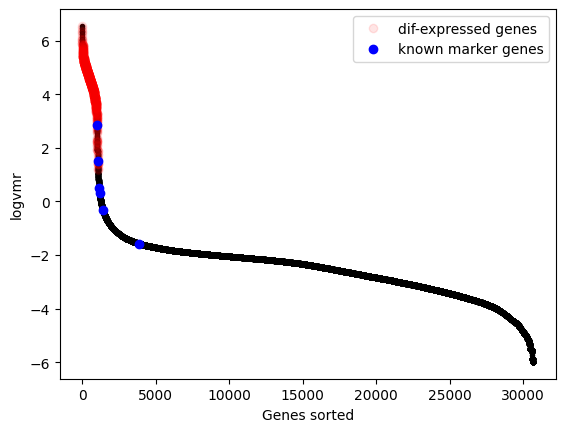

In [13]:
#genes=genes_all
#olfrs_all = olfrs_all_
#mean_expr_f = counts_across_olfrs_MAT.T
logvmr = np.log(np.nanvar(mean_expr_f,0)/np.nanmean(mean_expr_f,0))
good = ~(np.isnan(logvmr)|np.isinf(logvmr))
logvmr = logvmr[good]
genes_ = np.array(genes)[good]
genes_ = genes_[np.argsort(logvmr)[::-1]]
#mean_expr_f_ = mean_expr_f[:,good][:,np.argsort(logvmr)[::-1]]
gene_sel = [gn for gn in genes_ if ('olfr' not in gn.lower()) and ('taar' not in gn.lower())][:5000]

if False:
    bad_gns = []
    for gn in gene_sel:
        cts = counts_across_olfrs_MAT[genes.index(gn)]
        max1,max2 = np.sort(cts[~np.isnan(cts)])[-2:]
        if max2/max1>10:
            bad_gns.append(gn)
    len(bad_gns)
    gene_sel = [gn for gn in gene_sel if gn not in bad_gns][:1000]
    
    
y_ = np.sort(logvmr)[::-1]
x_ = np.arange(len(y_))
genes_all = np.array(genes)
genes_ordered_vmr = genes_all[good][np.argsort(logvmr)[::-1]]
keep1 = [gn in olfrs_all for gn in genes_ordered_vmr]
known_markers = ['Acsm4','Ncam2','Nqo1','Nrp2','Gstm5','Nfia']#,
keep2 = [gn in known_markers for gn in genes_ordered_vmr]
import matplotlib.pylab as plt
plt.figure()
plt.plot(x_,y_,'k.-')
plt.plot(x_[keep1],y_[keep1],'ro',alpha=0.1,label='dif-expressed genes')
plt.plot(x_[keep2],y_[keep2],'bo',label='known marker genes')
plt.ylabel("logvmr")
plt.xlabel("Genes sorted")
plt.legend()

In [15]:
import pandas as pd
T4 = r'C:\Users\duble\Dropbox\ORFigures\Figures2024\Tables\Table S4.xlsx'
df = pd.read_excel(T4, sheet_name=0,skiprows=1)
# Display the first few rows of the DataFrame
print(df.head())
ORsOB = np.array(df[' OSN type'])
XOB = np.array(df[[' position x (um)', ' position y (um)',' position z (um)']])
is_med = np.array(df[' medial projection'])

   Glomeruli index  OSN type   position x (um)   position y (um)  \
0                1  Olfr1022          -3826.73           1692.74   
1                2  Olfr1251          -3148.83           1662.73   
2                3  Olfr1251          -3311.87           1565.65   
3                4  Olfr1251          -2842.32           1651.65   
4                5  Olfr1251          -2620.16           1557.27   

    position z (um)   medial projection   lateral projection  
0           1270.82                True                False  
1           1235.27                True                False  
2           1264.65                True                False  
3           1209.41                True                False  
4           1260.32                True                False  


In [16]:
df = pd.read_excel(T4, sheet_name=1,skiprows=1)
# Display the first few rows of the DataFrame
print(df.head())
X_surface = np.array(df[[' position x (um)', ' position y (um)',' position z (um)']])

   Point index   position x (um)   position y (um)   position z (um)
0            0             -3500              1295              2485
1            1             -3500              1295              2555
2            2             -3500              1295              2625
3            3             -3500              1295              2660
4            4             -3500              1330              2765


C:\Users\duble\AppData\Local\Temp\ipykernel_19048\911657594.py:8: RuntimeWarning: All-NaN slice encountered
  expr_med = np.array([np.nanmedian([dic_ct_gn.get(ORsOB[r__],np.nan) for r__ in r_]) for r_ in res])


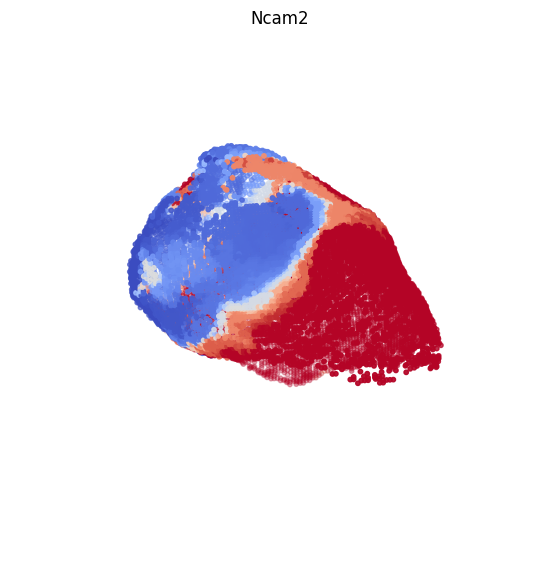

In [39]:
gene = 'Ncam2'
from scipy.spatial import KDTree
tree = KDTree(XOB)
res = tree.query_ball_point(X_surface,400)
genes = list(genes)
ign = genes.index(gene)
dic_ct_gn = {o:ct for ct,o in zip(mean_expr_f[:,ign],olfrs_all)}
expr_med = np.array([np.nanmedian([dic_ct_gn.get(ORsOB[r__],np.nan) for r__ in r_]) for r_ in res])
expr_med[np.isnan(expr_med)]=0
expr = np.log(expr_med+1) 

import os
from matplotlib import cm
gn = genes[ign]
fig = plt.figure(figsize=(7,7))
ax = plt.axes(projection='3d')
plt.title(gn)
res_ = 1
ax.scatter(X_surface[::res_,0],X_surface[::res_,1],X_surface[::res_,2],s=10,c=cm.coolwarm(expr[::res_]))
ax.set_axis_off()
ax.view_init(elev=-20., azim=280)
plt.show()

In [42]:
T3 = r'C:\Users\duble\Dropbox\ORFigures\Figures2024\Tables\Table S3.xlsx'
df = pd.read_excel(T3, sheet_name=1,skiprows=1)
# Display the first few rows of the DataFrame
print(df.head())


XMOE = np.array(df[[' position x (um)',' position y (um)']])
ORMOE = np.array(df[' OSN type'])

res=10
Ict = np.round(XMOE/res)
XSurf__MOE = np.array([eval(e) for e in np.unique([str(list(e))for e in Ict ])])*res

   OSN index  OSN type   position x (um)   position y (um)
0          1  Olfr1049           1398.30            225.69
1          2  Olfr1049           1409.48            242.42
2          3   Olfr806           1409.92            244.75
3          4  Olfr1181           1408.33            221.77
4          5   Olfr315           1406.13            201.19


In [43]:
gene = 'Ncam2'
from scipy.spatial import KDTree
tree = KDTree(XMOE)
res = tree.query_ball_point(XSurf__MOE,50)
genes = list(genes)
ign = genes.index(gene)
dic_ct_gn = {o:ct for ct,o in zip(mean_expr_f[:,ign],olfrs_all)}
expr_med = np.array([np.nanmedian([dic_ct_gn.get(ORMOE[r__],np.nan) for r__ in r_]) for r_ in res])
expr_med[np.isnan(expr_med)]=0
expr = np.log(expr_med+1) 

C:\Users\duble\AppData\Local\Temp\ipykernel_19048\755738961.py:8: RuntimeWarning: All-NaN slice encountered
  expr_med = np.array([np.nanmedian([dic_ct_gn.get(ORMOE[r__],np.nan) for r__ in r_]) for r_ in res])


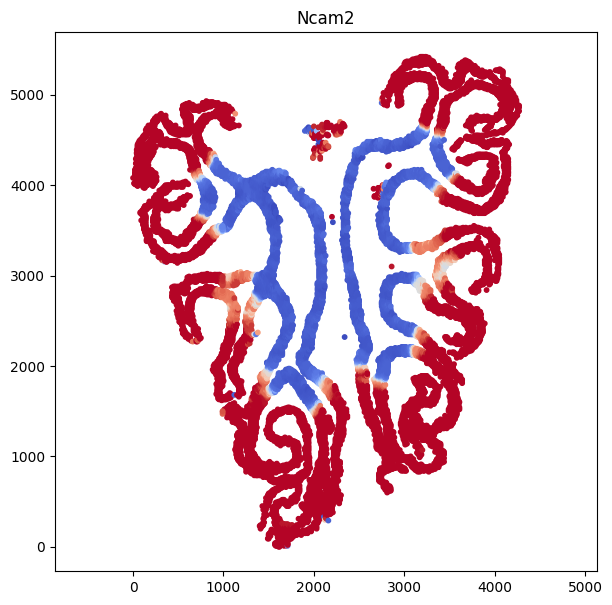

In [45]:
import os
from matplotlib import cm
gn = genes[ign]
fig = plt.figure(figsize=(7,7))
plt.title(gn)
plt.scatter(XSurf__MOE[:,0],XSurf__MOE[:,1],s=10,c=cm.coolwarm(expr))
plt.axis('equal')
plt.show()

In [14]:
dif_genes = ['Hbb-bs', 'Bpifa1', 'S100a5', 'Sult1c1', 'Cyp2a5', 'Apoe', 'Gm4181', 'Cbr2', 'Sec14l3', 'Cyp2g1', 'Hbb-bt', 'Rgs5', 'Chil4', 'Fxyd2', 'Hba-a1', 'Hba-a2', 'Malat1', 'Pcp4l1', 'Calm1', 'Gstm1', 'Wfdc18', 'Scgb1c1', 'Cyp2f2', 'Ppa1', 'Gap43', 'Reg3g', 'Cartpt', 'Tmsb4x', 'Bpifb3', 'Prdx6', 'mt-Rnr2', 'Actb', 'Sult6b1', 'Stoml3', 'Pon1', 'Nqo1', 'Akr1a1', 'Fmo6', 'Krt18', 'Cd14', 'Avp', 'Fcer1a', 'Dlg2', 'Rfk', 'Calb2', 'Fos', 'Omp', 'Car2', 'Tuba1a', 'Msln', 'Neurod1', 'Aqp3', 'Stmn2', 'mt-Cytb', 'Fth1', 'Mgst1', 'Sec14l2', 'Nupr1', 'Hsp90ab1', 'Jun', 'Crabp1', 'Acsm4', 'Cyb5a', 'Prdx1', 'Ctss', 'Pgrmc1', 'Edn2', 'Aldh2', 'Dpysl3', 'Gm44968', 'Cd36', 'Gm15971', 'Sox11', 'Ephx4', 'Agr2', 'Sult1d1', 'Lyz2', 'Col5a1', 'mt-Nd5', 'Sod1', 'Neat1', 'Krt23', 'Sprr3', 'Gm23935', 'Vim', 'Vmo1', 'Por', 'Cd55', 'Ubd', 'Atox1', 'Tubb5', 'Krt17', 'Hspb1', 'Papss2', 'Ermn', 'Srgn', 'Sdc4', 'Ckb', 'Ifitm1', 'Gm37194', 'Skp1a', 'Gng8', 'Ctgf', 'Gphb5', 'Tsc22d1', 'Cyp1a2', 'Tmbim6', 'Tshz1', 'Cpm', 'Tmsb10', 'AI314180', 'mt-Nd1', 'Gstm5', 'Aox2', 'Gm13762', 'Slc27a2', 'Il33', 'Gm14682', 'Cyb5r3', 'Map1b', 'Lypd2', '5430427N15Rik', 'Arl6ip1', 'Asb4', 'Atf3', 'Cd74', 'Gng13', 'Anxa1', 'Junb', 'Tubb2b', 'Casp3', 'Marcks', 'Calm2', 'Ankrd2', 'Blvrb', 'Gnal', 'Krt8', '4930469K13Rik', 'Slc7a14', 'Aqp4', 'Milr1', 'Tcim', 'Bglap3', 'Eef1a1', 'Fosb', 'Gm47449', 'Kcnk2', 'Gm27253', 'mt-Nd2', 'Stmn1', 'Scg2', 'Wfdc2', 'Aldh1a7', 'Gm10827', 'Scgb3a1', 'Stmn4', 'Ltf', 'H3f3b', 'Gnas', 'Ppp1r15a', 'Aqp5', 'Dapl1', 'Galm', 'Tex15', 'Clec7a', 'Dcn', 'mt-Co1', 'H2-Ab1', 'Fstl5', 'Gm13757', 'C1qb', 'Olfm1', 'H2-Aa', '4932412D23Rik', 'Rps9', 'Egr1', 'Socs2', 'Ubb', 'Dnah12', 'H2-Eb1', 'Mettl7a1', 'Ugdh', 'Btg2', 'Atp1b1', 'Sub1', 'Maob', 'Svopl', 'Atf5', 'Hspa1a', 'Dcdc2a', 'Rplp1', 'Slc30a3', 'Gm13742', 'Ltb4r1', 'Gm10264', 'Gm44196', 'Habp2', 'Gm42797', 'Colec10', 'Dusp9', 'Gm22019', 'C5ar2', 'Cmip', 'Slc16a11', 'C030015E24Rik', 'Gm22997', 'Gm12348', 'Lncbate1', 'Gm17572', 'Dab2', '3930402G23Rik', 'Hsp90b1', 'mt-Nd4', 'Tnfaip8l3', 'Gm10465', 'Sprr1a', 'Cyp2j6', 'Gm22571', 'Tenm2', 'Rps20', 'Rps14', 'Gm26978', 'Egln3', 'Gm43247', 'Gm37928', 'Ppfibp2', 'Gm805', 'Ces1d', '2900042K21Rik', 'Hnrnpa2b1', 'Rps26', 'Gm47346', 'Pabpc1', 'mt-Rnr1', 'Rgs12', 'Serpine2', 'Tppp3', 'Gm48704', 'Pcdh10', 'Gm27231', 'Socs3', 'Ivl', 'Ccrl2', 'Dcpp3', 'BC048644', 'Chga', 'Fcna', 'Gm18517', 'Gpx4', '4933434M16Rik', 'Htr1b', 'Tmem51os1', 'Sftpd', '1110032F04Rik', 'Trib3', 'Lrrc2', 'Gm26510', 'Nhlh1', 'Gm37738', 'Gm43341', 'Rps5', 'Ptma', 'Crabp2', 'Cebpg', 'Galnt12', 'Snora69', 'Gm26691', 'Gusb', 'Itgam', 'Gm17025', 'Gm43715', 'AC116487.1', 'Gm16158', 'Gsta4', 'Bcl2a1b', 'Ftl1', 'Gadd45g', 'Gm44249', 'Zfp92', 'Ddit3', 'Baiap2l2', 'Gm15481', 'Gm4724', 'Actc1', 'AC163720.3', 'Tmie', 'Gm47513', 'Tpt1', 'Gm9870', 'Tube1', 'Taldo1', 'Gucy1b2', 'Zfp735', 'Creg1', 'Ddx5', 'Gm45819', 'Mgll', 'Psmd14', 'OR5BS1P', 'F2rl1', 'Gm15966', 'B2m', 'Gm37352', 'Gm12867', 'Pdcd1', 'Rps3', 'Taf7l', 'Gm42772', 'Eif1', 'H1f0', 'Angpt1', 'Gm7493', 'Gm13193', 'Rpl26', 'Epcam', 'Gm25164', 'Cers1', 'Chchd2', 'Rps24', 'Mt1', 'Gm32281', 'Cisd1', 'Gm11471', 'Fat4', 'Vmn1r181', 'Kcnq1ot1', 'Cyp4v3', 'Gm43294', 'Tmprss11f', 'Cyp4b1', 'Wls', 'Ms4a1', 'Klf5', 'Slc4a7', 'Zfat', 'Osbpl1a', 'Wdhd1', 'Plk4', 'Txnrd1', 'Nrxn1', 'Gstm2', 'Hdac2', 'Gm13755', 'Kirrel2', 'Cyr61', 'Ncam1', 'Rpl32', 'Gzma', 'Gm49157', 'Rpl10', 'Gm16412', 'Fam213a', 'Gm43726', 'Gm19035', '2700068H02Rik', 'Gm6007', 'Gm13380', 'Gm37065', 'Calml4', 'Gm8261', 'Acadm', 'Elf5', 'AA467197', 'Gpr87', 'Cox6c', 'Gm15989', 'Gm13458', 'Rpl13', 'Gm26751', 'S100a1', 'Gm14529', 'Gm49215', 'Gm5', 'Il1b', 'Otx2', 'Kif5b', 'Gm18213', 'Anxa5', 'Rpl41', 'Coch', 'Itm2b', 'Tgm5', 'Stk32a', '2610044O15Rik8', 'Ccl4', 'Ier2', 'Rplp0', '1810028F09Rik', 'Neurog1', 'Gm48349', 'Foxi1', 'Ptpn14', 'Fndc5', 'Gadd45b', 'Gm7534', 'Cd209g', 'Limd2', 'Hspa5', 'Igfbp5', 'Gm5709', 'Rprm', 'Gm5912', 'Rflnb', 'AC147983.2', '2900078I11Rik', 'Gm10997', 'Clmn', 'Atp8b4', 'Rslcan18', 'Csrp2', 'Klf4', 'Gm14403', 'Gm14798', 'Gm44830', 'Gm22506', 'Cotl1', 'Zp2', 'Pappa2', 'Gm24576', 'Gm47490', 'Gm26526', 'Dcxr', 'Cox8a', 'Cnn2', 'Vwa2', 'Parva', 'Ptger2', 'Galnt18', 'Hsp90aa1', 'Entpd5', 'Ubl3', '1500015O10Rik', 'Gm12906', 'C1qc', 'Il1r2', 'Gm37858', 'Krt14', 'Rnf144a', 'Gm4222', 'Rpl4', 'Gm7494', 'Sult1e1', 'Zfp169', '5430403N17Rik', 'Cdkn1a', 'Gm20281', 'Rrh', 'Ndufa4', 'Ptn', 'Kdelr3', 'Gnmt', 'Chrne', 'Fam229a', 'Cyb561a3', 'Pqlc3', 'Stom', 'Gm10548', 'Barhl1', 'Mgp', 'Gucy2d', 'Gm8503', 'Cd9', 'Gm15718', 'Gpx1', 'Gm43815', 'Atxn7l3b', 'Zfp36l1', 'AU021092', 'Ifi202b', 'Rpl11', 'Gm7209', 'Hist3h2ba', 'Chil6', 'Rps12', 'Gm10284', 'Rtn1', 'Ifi209', 'Wif1', 'Ric8b', 'Olig1', 'Uchl1', 'Nos1', 'Cdc42ep5', 'Klf15', 'Gm9317', 'Mir200c', 'Galnt6', 'Gm8190', 'Fam213b', 'Cnn3', 'Cryab', 'Dusp14', 'Adi1', 'Arc', 'Mcm10', 'Rs1', 'Stx11', 'Snx7', 'Gm44693', 'Tcf4', 'Ezr', 'Plcb1', 'Gm45200', 'Esam', 'Gm14984', 'Gm44697', 'Rpph1', 'Gm13502', 'Gm8575', 'Epha5', 'Tmprss2', 'Nfib', 'Homer2', 'Myo6', 'Plppr5', 'Rps15', 'Pzp', 'S100a6', 'Gm48554', 'Gm17992', 'Klf6', 'Ece1', 'Rtl4', 'Gm46364', 'Aplp2', 'Cnpy1', 'Hist1h1b', 'Nr4a1', 'Slitrk5', 'Serbp1', 'D830036C21Rik', 'Clta', 'Gm10493', 'Gm14828', 'Ebf1', 'Rps2', 'Gtf2b', 'Neurl1b', 'Atp2a1', 'Marcksl1', '1810049I09Rik', 'Ptgr1', 'Tax1bp1', 'Gm15580', 'Mogat1', 'Tmem213', 'Defb42', 'Eya4', 'Ascl3', 'Dnajb1', 'Gm42680', 'Snca', 'Clu', 'Gm4954', 'Epas1', 'Ccr7', 'Rplp2', 'Chchd10', 'Slc25a35', 'Gm35909', 'Gm16027', 'Gm14845', 'Gm12664', 'Ldhb', 'Rps27a', 'Nexmif', 'Gm5561', 'Rpl18a', 'Tubb3', 'Efna5', 'Gm5915', 'Mapt', 'Gm8436', 'Gm44050', 'Ncl', 'Rps16', 'Plekhb1', 'Gm20939', 'Kcnj13', 'Pcdh8', 'Id1', 'Sox2', 'Nucb2', 'Rmdn3', 'Tagln2', 'Fmo2', 'Zfp36', 'Arhgdig', 'Txn1', 'Hsd17b11', 'Olig2', 'Gm42635', 'Pdap1', 'Sgpl1', 'Anxa2', 'Cd63', 'Nhlh2', 'Bmp2', 'Hnrnpab', 'Cldn4', 'Rpl8', 'Gm11769', 'Il6', 'S100a11', 'Ipcef1', 'Pfn1', 'Ier3', 'Soat2', 'Spta1', 'Kif5c', 'Elavl3', 'Gm13803', 'Itpripl1', 'Mex3a', 'Cebpd', 'Tshz2', 'Gm15454', 'Xkr8', 'Gm16052', 'Gm12004', 'Uncx', 'Faiml', 'Ocm', 'Acoxl', 'Jpt1', 'Pnn', 'Hes1', 'Gm42732', 'Gm48272', 'Pou4f1', 'Pawr', 'BC022960', 'Gnb1', 'Bpifb1', 'Tspan2', 'Sh3bgrl', 'Alcam', 'Pcdh17', 'Cryl1', 'Alas1', 'Tff2', 'Dtl', 'Gm13570', 'App', 'Fut9', 'Tro', 'Rps7', 'Rpl19', 'C430039J01Rik', 'Gm23833', 'Qpct', 'Arl5c', 'Hist1h2ad', 'Ephx1', 'Serpina1d', 'Sat1', 'Rbm39', 'Tex33', 'Gas2l3', 'Lpgat1', 'Rps10', 'Pdlim5', 'Spint2', 'Gm13179', 'Nrgn', 'Gm7979', 'Dusp1', 'Ociad2', 'Rpl21', 'Gm16253', 'Pcbp2', 'Fbp2', 'Itga11', 'Cdkn1c', 'Trim68', 'Nedd4', 'Ccnd1', 'Clic6', 'Psip1', 'Dio2', 'Rpl27a', 'C1qa', 'Bdnf', 'Tgfb2', 'Gfy', 'Gm38319', 'Cox6a1', 'Map1lc3a', 'Cystm1', 'Ap3m1-ps', 'Hint1', '5330411J11Rik', 'Eaf2', 'Gm13761', 'Slc9a3r2', 'Vapa', 'Gm44091', 'Ubc', 'Slc25a45', 'Luc7l3', 'Gm7973', 'Htr2c', 'Ube2q2', 'Med21', 'Ybx1', 'Hist2h2be', 'Rgs1', 'Oas1g', 'Pdlim1', 'Gm44250', 'Gchfr', 'Dennd2c', 'Cd80', 'C9', 'Rpl14', 'Ccdc18', 'Smbd1', '4930417O13Rik', 'Alox8', 'Gm16069', 'Tst', 'Gm16570', 'Gm45941', 'Cd47', 'Hmgn3', 'Rps8', 'Amotl1', 'Aqp10-ps', 'Nuak1', 'Lrrc3b', 'Stmn3', 'Ppia', 'Tkt', 'Tenm4', 'Phb2', 'Nampt', 'Gm7324', '9430025C20Rik', 'Gm23639', 'Mfsd3', 'Nr4a2', 'Clgn', 'C130023A14Rik', 'Tyrobp', 'Gm43117', 'Col24a1', 'Gm44168', 'Gm49154', 'Acss2', 'Usp35', 'Gm42514', 'Amotl2', 'Pcdh11x', 'Fau', 'Nov', 'Gm12961', 'Zfp955a', 'Hspa8', 'Gm1821', 'F830016B08Rik', 'Rps3a1', 'Gm42851', 'Myl6', 'Gm11264', 'Dynll2', 'Rps19', 'Lars2', 'Pde1c', 'Gng2', 'Fetub', 'Slc25a25', 'Fam122b', '5530401A14Rik', 'Rpl17', 'Npas2', 'Ncam2', 'Trim63', 'Gm4034', 'Rpl9', 'Dusp2', 'Gng3', 'Tyro3', 'Gm6640', 'Gm29036', 'Atp6v1b1', 'Spef2', 'Gm12661', 'Ift88os', 'Prim2', 'Spcs2', 'Kbtbd4', 'Gm12112', 'Gm2559', 'Aamdc', 'Rps11', 'Aqp11', 'Ccl3', 'Il6ra', 'Pgm2l1', 'Gm7412', 'Slc12a2', 'Ccl8', 'Gm7389', 'Abcd2', 'Nsg1', 'Cox4i1', 'Gm4651', 'Gm11533', 'Sox4', 'Gldn', 'Gabarapl1', 'Gm7722', 'Camk2n1', 'Gm14861', 'Mbl2', 'Bcl11b', 'Lmntd1', 'Akap9', 'Tymp', 'Naca', 'Gm13038', 'Kcnmb3', 'Rpl23a', 'Iqgap2', 'Rps27l', 'Dync1i2', 'Mef2b', 'Uqcrh', 'Fbxo17', 'Prickle3', 'Gsta3', 'Gcsam', 'Phtf1', 'Psma7', 'Gm12834', 'Eif4g2', '1700012B09Rik', 'Selenom', 'Rab3c', 'AC135736.1', 'Zfp507', 'Ampd1', 'Snta1', 'A2ml1', 'Gm11413', 'Jarid2', 'Rps15a', 'Col5a3', '1700093K21Rik', 'Abcd3', 'Ccnl1', 'Gm44187', 'Gm48985', 'Pola1', 'Gm11955', 'Gm28512', 'Lmo7', 'Gm7967', 'Tspan13', 'AC154478.1', 'Gm10282', 'Myl12a', 'Cyp2a21-ps', 'Mslnl', 'Ywhab', 'Syt11', 'Gm12003', 'Gm3696', 'Nipal1', 'Aldh1a1', 'Son', 'Gm15744', 'Chd4', 'Lad1', 'Pnisr', 'Gm6061', 'Pigr', 'Csnk1a1', 'Gm32102', 'Kitl', 'Kcnk1', 'Lima1', 'Nsg2', 'Rpl3', 'Cox6b1', 'Pot1b', 'Ube2k', 'Fbxo48', 'Atp6v1c2', 'Srrm2', 'Sord', 'Sh3pxd2b', 'Gpc2', 'Sh2d7', 'Gm13445', 'Cdv3', 'Gm45199', 'Tceal9', 'Cmtm8', 'Bmpr1b', 'Mettl7a2', 'Gnao1', 'Meis2', 'Gm8472', 'Cldn3', 'Rps27', 'Nr3c1', 'Gm48808', 'Gm7252', 'Eif5b', 'Atf4', 'Rps18', 'Top2a', 'Rps13', 'Tspan8', 'Cyp2a4', 'Sfrp1', 'Mt2', 'Mgst3', 'Gm6134', 'Scp2', 'Gm8816', 'Nudt11', 'Rbm25', 'Klre1', 'Rps21', 'Serp1', 'Sparcl1', 'Igfbp7', 'Eif3a', 'Syt2', 'Cldn7', 'Dlx5', 'Gm7123', 'Nectin3', 'Gas5', 'Gm47220', 'Kif2c', 'Rab10', 'AC121960.1', 'Hlf', 'Slc6a13', 'Tas2r104', 'Gm26403', 'Gm15107', 'Gm15496', '4921522P10Rik', 'Clec4b2', 'Aldh3b3', 'Gm48607', 'CT025521.3', 'Gm46355', 'Gm13029', 'Gm45015', 'Egr2', 'Vmn2r38', 'Tas2r123', 'Gm13180', '4930555F03Rik', 'Gpr119', 'Gm24092', 'Gm17834', 'Gm21009', 'Fgf15', 'AC117232.1', 'Fcrl6', 'Gm31630', 'Gm39336', 'Ttll2', 'Gm29521', 'Gm15159', 'Ifitm3', 'Rnd3', 'Hey1', 'Gm48124', 'Hist1h2bc', 'Adcy3', 'Gm48232', 'Rnasel', 'Ttc3', 'Necab2', 'Rgs17', 'Hmcn2', 'Tmtc1', 'Gm48254', 'Atrx', 'Sem1', '4933431M02Rik', 'Lancl3', 'Mrpl54', 'Ctxn3', 'Gm7783', 'Gm48933', 'Gm12162', 'Kcnj5', 'Lilr4b', 'Fxyd6', 'Dynlt3', 'Gm36298', 'Mettl27', 'Baz1a', 'Rpl7', 'Top1', '1700064M15Rik', 'Eng', 'B230377A18Rik', 'Gm26643', 'Ssx2ip', 'Laptm4a', 'Recql4', 'Gm7446', 'Hist1h1c', 'Rpl23a-ps9', 'Gm10941', 'Gm14302', 'Arpp21', 'Ezh2', 'Gm7988', 'Saraf', 'Gm48557', 'Runx1t1', 'Ckap4', 'Il13ra2', 'Atp5f1', 'Gm12216', 'Cbln2', 'AC121960.2', 'Smtnl1', 'Arl15', 'BC021767', 'Dpep2', 'Gm9661', 'Gm29541', 'Cd40lg', 'Aurkb', 'Prrc2c', 'Shprh', 'Scn9a', 'Cdkn1b', '1500011K16Rik', 'Eif3c', 'Herpud1', 'Lipg', 'Gm12500', 'Rpl6', 'Cst3', 'Mios', 'Gm43810', 'AC165953.3', 'Gm44508', 'Mapk1ip1l', 'Gm37377', 'Atp6v1a', 'Slc51a', 'Hnf1a', 'Canx', 'Draxin', 'Gm6869', 'Gm8048', 'Ablim1', 'Nktr', 'Dph7', 'Mitf', 'Arpc2', 'Rn7sk', 'B230112J18Rik', 'Npb', 'Pcolce2', 'Rpsa', 'Eif3f', 'Ms4a7', 'Dstn', 'Gm43103', 'Gm5350', 'Phldb3', 'Rtn4', '9530013L04Rik', 'Rhod', 'Gm12565', 'Cd81', 'Procr', 'Baz2b', '1810008I18Rik', 'Cib1', 'Hist1h4c', 'Cldn6', '2610035F20Rik', 'Ly9', 'Pde8b', 'Rab26', 'Anxa11', 'Gm10770', 'Gm49021', 'Fv1', 'Gm15455', 'Doc2a', 'Myl12b', 'Fbxl7', 'Mef2a', 'Taf15', 'Qdpr', 'Gm3896', '1700023H06Rik', 'Pcdh7', 'Smc1b', 'Nrep', 'Gm42717', 'Gatsl3', 'Gm14200', 'Aldoa', 'Maff', 'Gm32389', 'Larp7', 'Pxylp1', 'Luzp1', 'Hspb8', 'Abca13', 'Prnp', 'Gm31931', 'Psmb1', 'Abca9', 'Gm42655', 'Gm47790', 'Gm48517', 'Gm38248', 'Gm6382', 'Nmb', 'Gm37411', 'Rpl37', 'Fcrl1', 'Gm2719', 'Tpr', 'Slc5a8', 'Rps17', 'Gm17655', 'Hcfc1r1', 'Gm6290', 'Rdx', 'Gm43793', 'Gm42776', 'Nhsl1', 'Atp2b1', 'Rsrp1', 'Mir8120', 'A830011K09Rik', 'Ypel1', 'Gal3st2c', 'Pxt1', 'Gm14870', 'Rpl23a-ps14', 'Gm12151', 'Gm12744', 'Pole3', 'Pdia3', 'Ndufv3', 'Gm6430', 'Gm42941', 'Prr5l', 'Pald1', 'AC102902.1', 'Golga4', 'Gm34391', '2310068J16Rik', 'Wdyhv1', 'Gm37859', 'Atp5d', 'Zfhx4', 'Emb', 'Dnase2a', 'Gm4587', 'Ywhae', 'Gsc', 'Gm44686', 'Gm6230', 'Rps6', 'Stard9', 'Ktn1', 'Gm7451', 'Eef1b2', 'Hnrnpc', 'Sept3', 'B630019A10Rik', 'Acin1', 'Bzw2', 'Zdhhc23', 'Klkb1', 'Traf3ip3', 'Ap3s1', 'Gm8111', 'Gm29767', 'Gm5070', 'Diaph1', 'Gm43394', 'Ubr7', 'Rpl7a', 'Ppp3ca', 'Gm6893', 'Wwtr1', 'Hnrnpul2', 'Pon3', 'Rpl18', 'Gm17199', 'Sptbn1', 'Gm45151', 'Atp5h', 'Emx2os', 'Gm49201', 'Gm44622', 'Gm16755', 'Dscc1', 'Nr4a3', 'Il12rb2', 'Gm4129', 'Camkv', 'Macf1', 'Ccdc28a', 'Gm15263', 'Thbs1', 'Fus', 'Slc14a1', '5730403I07Rik', 'Ebf2', 'Gm44840', 'Rpl22', 'Nrp2', 'Gm48860', 'Cap2', 'Gm15766', 'Syt4', 'Phip', 'Ywhaz', 'Sfn', 'Ube2c', 'Scpep1', 'Gm42763', 'Kif19a', 'Gm10244', 'Gm37570', 'Asb17', 'Gm48581', 'Gm7554', 'Gm18584', 'Esf1', 'Gm17060', 'Pinx1', 'Gm24303', 'n-R5s28', 'Pcbd1', 'Gm21631', 'Ivns1abp', 'Xaf1', 'Hebp2', 'Id4', 'Rps23', 'Prph', 'Tenm1', 'Gm44021', 'Il15', 'Tnfsf12', 'Cd302', 'Trpc3', 'Gm17102', 'Ly6e', 'Rhobtb3', 'Gm36948', 'Gm43081', 'St3gal6', 'Gm6203', 'Gm24492', 'Eya1', 'Sass6', 'Sphkap', 'Bach2', 'Ctsl', 'Gm4262', 'Kcnrg', 'Ggt7', 'Rpl5', 'Phf3', 'Polr2a', 'Gm9432', 'Gm8126', 'Cacna1f', 'Virma', 'Smc4', 'Cfl1', 'Gm35060', '2010007H06Rik', 'Enah', 'Dner', 'Tacstd2', 'Gm48853', 'Hmgn1', 'Fbxo2', 'Fcer1g', 'Rabac1', 'Gm29773', 'Slc25a5', 'Tpx2', 'C030029H02Rik', 'Wdr73', '1700073E17Rik', 'H2-M10.3', 'Taf7', 'Gm29753', 'Gm49024', 'Chst1', 'Gm4825', 'Calm3', 'Cadm1', 'Nipbl', 'Arrdc3', 'Gm37444', 'Rpl31-ps7', 'Faim2', 'Gucy1a2', 'Nadsyn1', 'Daw1', 'Tm9sf3', 'Gm10451', 'Gm16373', 'Gm47469', 'Srsf3', 'Gm26599', 'Gm40617', '4933427E11Rik', 'Tmprss4', 'Cacng4', 'Prdx2', 'Hist1h4k', 'Dpf2', 'Rps29', 'Terb1', 'Gm20594', '4930425P05Rik', 'Hectd2os', 'Gabarap', 'Snai2', '1700018A23Rik', 'F3', 'Nolc1', 'Rgs2', 'Gm10466', 'Rpl30', 'Kcnd1', 'Basp1', '2810001G20Rik', 'Fnbp1l', 'Ifrd1', 'Tubb2a', 'Cct6b', 'Zfp738', 'Gramd1c', 'Zbtb8os', 'Rbm47', 'Acadl', 'Gm15566', 'Tceal3', 'Klf7', 'Ncoa3', 'Rack1', 'Zfp605', 'F2r', '4930413G21Rik', 'Sltm', 'Rsf1', 'Gm38082', 'Rpl27', 'Gm13421', 'Dhx36', 'Gm16298', 'Ccdc85a', 'Tes', '9330102E08Rik', 'Edil3', 'Gm11438', 'Emx2', 'Mdh1', 'Arpc1a', 'Il13ra1', 'Gm12108', 'Oaz1', 'Fuca2', 'Baat', 'Gm2553', 'Cdyl2', 'Faim', 'Slc5a1', 'AC034116.4', 'Optn', 'Tnk1', 'Atp5j', 'Hnrnph1', 'Rpl12', 'Hdlbp', 'Dclk1', 'Thsd4', 'Mpv17l', 'Gm13998', 'Gm49189', 'B430218F22Rik', 'Tcp1', 'Fcrls', 'Gm22933', 'Rapgefl1', 'Rasip1', 'AC162302.2', 'BC005537', 'Scarna17', 'Tmod3', 'Vmn2r3', 'Zfp609', 'Xbp1', 'Depdc7', 'Rasl12', 'Hnrnpa3', 'Gm4353', 'Sec62', 'Dynll1', 'Rpl31', 'Tmem123', 'Lcp1', 'Anp32a', 'Scarna2', 'Id2', 'Dpy30', 'Rnase1', 'Slc38a6', 'Col4a5', 'Fads2', 'Gm13270', 'F420014N23Rik', 'St8sia6', 'Kif16bos', 'Ankrd12', 'Gm18791', 'Myo18a', 'Chpt1', 'Gm24588', 'Rims3', 'Srsf5', 'Ppig', 'Epb41', 'Gm10524', 'Eef2', 'Ppard', 'Gm8483', 'Nin', 'Nemf', 'Ubxn4', 'Gm11334', 'Nrp1', 'Gm41271', 'Ar', 'Gm37770', 'Gpm6b', 'Dcx', 'Gm18988', 'AC121965.1', 'Uqcrq', 'Mycbp2', 'Usp21', 'Ptms', 'Ccp110', 'Frk', 'Il17d', 'Cnbp', 'Kdm5b', 'Smg1', 'Atp5b', 'Spdef', '1700018A04Rik', 'Hist1h2bl', 'Pmf1', 'Gclm', 'Zfp82', 'Tas2r108', 'Slc25a24', 'Rasl11a', 'S100a14', 'Dek', 'Jph1', '6530409C15Rik', 'Zfp608', 'Pafah1b1', 'G3bp2', 'Cers6', 'Zfp40', 'Zfp37', 'S100a8', 'Cdc42', 'Mdk', 'Atp6v1f', 'Gm8216', 'Ly6g6d', 'Tirap', 'A630072M18Rik', 'Prdm8', 'A630072L19Rik', 'Gm42672', 'Dhdh', 'Rgs22', 'Pcdhga3', 'Rab6b', 'Ak1', 'Atp5e', 'Gm48478', 'Impa2', 'Gm48630', 'Brd8', 'Gm38386', 'Dapp1', 'Gpr155', 'Col9a2', 'Gm42463', 'Sbk1', 'Acr', '4930537H20Rik', 'Ncaph', 'Poc1b', 'Wdr78', 'Gpx6', 'Tspan33', 'Acsl3', 'Nfkbia', 'Hykk', 'Gm16477', 'Arhgef2', 'Prkx', 'Gm4165', 'Cldn10', 'Myh7', 'Zfp575', 'Esm1', 'Rgs16', 'Gm4117', 'Reep5', 'Gm33148', 'Gm6286', 'Arpc5', 'Rab27b', 'Alad', 'Pgbd1', 'Bod1l', 'Lrrc36', 'Ypel3', 'Akap12', 'Nrn1l', 'Ptar1', 'Msi2', 'Zbtb20', 'Cenpf', 'Atoh7', 'Trim16', 'Tecr', 'Rnf112', 'Scg3', 'Cox7b', 'Dcaf17', 'Ctnna1', 'Pard3', 'Cntn1', 'Crlf2', 'Mir7688', 'Slc31a1', 'Gm42666', 'Gm14989', 'Rgs7bp', 'Rpl21-ps6', 'Gm15616', 'Gm43903', 'Gm12987', 'Eid1', 'Gm26614', 'Ankrd22', 'Ddah2', 'Parp2', 'Hmgn5', 'A430027H14Rik', 'Gm45481', 'Gnb2', 'Adipor1', 'Whamm', 'Mb', 'E330011O21Rik', 'Tjp1', 'Platr31', 'Smarcd2', 'Sgk1', 'BC028528', 'Mmp2', 'Robo2', 'Areg', 'Mzb1', 'Dscaml1', 'Gm44639', 'Pcf11', 'Acsl4', 'Pcdh9', 'Gm20177', 'Gm45183', 'Gm15808', 'Abhd14b', 'Mutyh', '2610507B11Rik', 'Gm15587', 'Zbtb45', 'Arl6ip4', 'Syndig1', 'Lipc', '1700016A09Rik', 'Gm48018', 'Rps4x', 'Pcdhac2', 'Lgr5', 'Ndufa2', 'Gm14630', 'D630003M21Rik', 'Il1r1', 'Gm5212', 'Gm3150', 'Tpm3', 'Thoc2', 'Gm13981', 'Gm15564', 'Gm10684', 'Slc15a2', 'Rpl21-ps2', 'Spock1', 'Marveld2', 'Cyp4f40', 'Rpl35a', 'Wdr66', 'Srp14', 'Ina', 'Rps25', 'Gm25327', 'Gsk3b', 'Nicn1', 'Gm15727', 'Ube2b', 'Eif5', 'Numbl', 'Pard3bos1', 'Mocs2', 'Smyd3', 'Gm43884', 'Itpr2', 'Rpl28', 'Cox7a2', 'Mical1', 'Aicda', 'Luc7l2', 'Sntg1', 'Comp', 'Gm24124', 'Rbmx', 'Sept7', 'Bmp3', 'Lhfpl3', 'Gm17218', 'Hes6', 'Snrnp70', 'AC154691.1', 'Cstb', 'Zfx', 'Mia3', 'Gm42769', 'Tspan7', 'Aldoc', 'Apc', 'Adgrg2', '4732471J01Rik', 'Evi2a', 'Gm6506', 'Gm13509', '4833412C05Rik', 'Manea', '4933407L21Rik', 'Zfp397', 'Gm45640', 'Neurod4', 'Klhdc8a', 'Gm44971', 'Crip1', 'Gm45772', 'Gm45222', 'Csmd3', 'Mfsd8', 'Ralbp1', 'Bpifb4', 'Ndrg1', 'Mecom', 'AC134548.1', 'S100a16', 'Gm25911', 'Zfp90', 'Gm5706', 'Mlxipl', 'Gm43799', 'Nol8', 'Prpf40a', 'Apopt1', 'Gm2694', 'Svil', 'Laptm5', 'Dnaja1', 'Gm19582', 'Cit', 'Engase', 'Amd1', 'Smarcc1', 'Acbd7', 'Rps12-ps7', 'Hook3', 'Gm48298', 'Zfp52', 'Gm20628', 'Srsf7', 'Rtp1', 'Ccdc88c', 'F7', 'H2afv', 'Zfp462', 'Slc37a2', 'Gm7943', 'Plat', 'Dusp7', 'Lifr', 'Mfng', 'Arid5b', 'Gm14706', 'Nudt4', 'Cenpj', 'Cdh26', 'Tbr1', 'Rab6a', 'Sox9', 'Miat', 'Psma2', 'Atpif1', 'Celf4', 'P4hb', 'Fubp1', 'Upb1', 'D1Ertd622e', '1110019D14Rik', 'Gm5257', 'Rpl23', 'Scgn', 'Vamp5', 'Slc35d1', 'Cntn4', 'Gdf11', 'Mum1l1', 'Mtdh', 'Arpc5l', 'Tesc', 'Gm996', 'Ccdc59', 'Psmb4', 'Selenow', 'Ndst1', 'Gm29395', 'Clec12a', 'Lhx6', 'Slc6a14', 'Efs', 'Acss2os', 'Ctsh', 'Efcab5', 'Gm47681', 'Plod1', '1810012K16Rik', '1700039E22Rik', 'Gm16465', 'Zap70', 'Orai1', 'Il25', 'Gm49204', 'Platr14', 'Gipc2', 'Gm49153', 'Tcea1', 'Plk2', 'Gm26681', 'Wdr24', 'Hddc2', 'Lrfn1', 'Hbegf', 'Pitx1', 'Nrxn3', 'Gm13772', 'B9d1os', 'Ndufa13', 'Bcl2a1a', 'Rpl34', 'Flrt1', 'Reln', 'Steap2', 'Uaca', 'Tfeb', 'Rpl37a', 'Selenok', 'Slx4', 'Gm12419', 'Emd', 'Zdhhc15', 'Dynlrb1', 'Cpsf6', 'Crot', 'Cenpe', 'Abcb6', 'mt-Nd6', 'Gm13454', 'Gm14723', 'Fhdc1', 'Insm1', 'Gm5874', 'Nlk', 'Zfand5', 'Gm14037', 'Tra2a', 'Gm22822', 'Ctnnd2', 'Gm48780', 'Ago2', 'Pkm', 'Morf4l2', 'Ythdf2', 'Gm14506', 'Gm9264', 'Tma7', 'Hsd17b12', 'Ncor1', 'Mal', 'U2surp', 'Slc39a2', 'Gm3145', 'Maoa', 'Selenok-ps5', 'Bmp1', 'Gm3333', 'Gm44116', 'A930028N01Rik', 'Map1lc3b', 'Gm6881', 'Rtn3', 'Adam28', 'Ssb', 'Ccl20', 'Gm17053', 'C330022C24Rik', 'Slc4a4', 'Coil', 'Cox5b', 'Gm45069', 'Gm40770', 'Gm42845', 'Nap1l1', 'Brd3', '2310014F06Rik', 'Tgif2', 'Magi3', 'Fnta', 'Ifi27', 'Mob4', 'Suv39h1', 'Bcl7a', 'Wrn', 'Atp5c1', 'Gm7482', 'Pcm1', 'Ryr3', 'Hyal3', 'Cybb', 'Sh2b2', 'Nob1', 'Ackr3', 'Gm19290', 'Nr2c1', 'Parvaos', 'Gm45493', '1700015C15Rik', 'Tead1', 'Cbr1', 'Strbp', 'Samd5', 'Rpl15', 'Nfix', 'Vav3', 'Rock1', 'Gpsm1', 'Nrip1', 'Serpinb6a', 'Tmem159', 'Gm12269', 'Fam159a', 'Tmem267', 'Cd69', 'Gpm6a', 'Plekha7', 'Gm5678', 'Slco3a1', 'Rbx1', 'Lzts3', 'Gm13483', 'Gm19840', 'Gm19056', 'Srsf11', 'Elob', 'P3h1', 'Gm37636', 'Gm16174', 'Ntrk2', 'Calr', 'Smc6', 'Gpx2', 'Arhgef4', 'Nop10', 'Snx24', 'Nop58', 'D230017M19Rik', 'Gm43368', 'Tpm4', 'Gm9231', 'Tbcel', 'Mosmo', 'B230206L02Rik', 'Tob2', 'C530005A16Rik', 'Hist1h3d', 'Plag1', 'Gm27254', 'Cdh1', 'Pbrm1', 'Arid4b', 'Cfap36', 'Cldn25-ps', 'Gm44109', 'Mybl1', '2310015A10Rik', 'Fancd2', 'Thsd7b', 'Zc3h13', 'Ccar1', 'Tgfa', 'Gm16143', 'Resp18', 'Macrod1', 'Dhx9', 'Six1', 'Abca8b', 'Dnajb9', '1700074H08Rik', 'St6gal1', 'Ift74', 'Tmem74bos', '9030612E09Rik', 'Prpf4b', 'Tbca', 'Gtf2i', 'Fmnl2', 'Gm38093', 'Gm15868', 'Gm7508', 'Gm2991', '4933400F21Rik', 'Idh1', 'Fmr1', 'Gm31557', '1700084E18Rik', 'Gpc1', 'Zfp128', 'Gm44287', 'Fam126a', 'Slc35d3', 'Chchd7', 'Cldnd1', 'Rnf219', 'Gtpbp4', '4931440P22Rik', 'Cntln', 'Eif5al3-ps', 'Serpinb11', 'Appl1', 'Cbx1', 'Gm16056', 'Vps13c', 'Fgl2', 'Ckmt1', 'Gm26521', 'Bsg', 'Cxadr', 'Large2', 'Dmkn', 'Gm12035', 'Hnrnpm', 'Nfkbiz', 'Kdm5a', 'Gm34307', 'Paip2', 'Gm6611', '9130221H12Rik', 'Cfap20', 'Cmpk1', 'Elf3', 'Gm26604', 'Zbtb8a', 'Gm42613', 'A830009L08Rik', 'Cdk4', 'Mboat1', 'Prrg1', 'Prss8', 'Rem2', 'Gm42943', 'Crmp1', 'Rrp1', 'Fkbp4', 'Mamstr', 'Dnaja2', 'Scn3a', 'Gm37376', 'Fam149b', 'Sf3b1', 'Eif4a2', 'Mras', 'Gm27935', 'Cox5a', 'Gm42893', 'Cidea', 'Gm16876', 'Col9a3', 'A430035B10Rik', 'Fam13c', 'Clic4', 'Nr2f2', 'Patj', 'Atp6v0e', 'Gmpr', 'Gm42919', 'Armcx6', 'Irf1', 'Rbbp6', 'Erbb4', 'Gm15396', 'Yy1', 'Gm5464', 'Gm42455', 'Wars2', 'Col4a2', 'Mthfd1', 'Sfpq', '4930528D03Rik', 'Ccdc88a', 'Pgap2', 'Mtf2', 'Snhg17', 'Mtrf1l', '4930430A15Rik', 'Mapk11', 'Sec61b', 'Gm29736', 'Npffr1', 'Ccdc186', 'Pde4a', 'Trmt112-ps2', 'Steap1', 'Brinp1', 'Myt1l', 'Smchd1', 'Gm25772', 'Jakmip1', 'Gm31166', 'Tsn', 'Pramef8', 'Mapre1', 'Dbn1', 'Gm39168', 'Agpat2', 'Rabep1', 'Hmgb3', 'Ccdc15', 'Copb1', 'Jak1', 'Hnmt', 'Gm47918', 'Map7d2', 'Ormdl3', 'Lap3', 'Cers4', 'Psmd8', 'Golgb1', 'Pex26', 'Ikzf4', 'Trp53cor1', 'Gm26649', 'Rspo4', 'Ahi1', 'Ptprf', 'Bean1', 'Myo10', 'Ano9', '4632415L05Rik', 'Srm', 'Wipi1', 'Atp5g3', 'Ccdc82', 'Rbms1', 'Rbm11', 'Vamp7-ps', 'Lrriq1', 'Gm6564', 'Tmem234', 'Rsrc2', 'Plek', 'Snhg8', 'Kctd7', 'Zmynd11', 'Plekha5', 'Pik3r1', 'Hnrnpdl', 'Pfdn5', 'Brf2', '1700001J03Rik', 'Nlk-ps1', 'Pkia', 'Slc25a10', 'Gm12631', 'Sh3rf1', 'Dkkl1', 'St13', 'Gm28370', 'Hsph1', 'Pik3cd', 'Gipc1', 'Srp19', 'Gm45292', 'Ank2', 'AC078895.1', 'Tjp3', 'Anp32e', 'Lamp1', 'Gm10418', 'Cgref1', 'Gm13648', 'Smarca5', 'Nabp1', 'Abcc3', 'Fyb', 'Gm48313', '1700047K16Rik', 'Kdm1b', 'Atp5o', 'Sqstm1', 'Lrrc29', 'Gm48249', 'Sc5d', 'Ttc12', 'Umodl1', 'Svep1', 'Gm16228', 'Ost4', 'Gm47112', '6230400D17Rik', 'Zfp326', 'Zc3h15', 'Ndufb11', 'Cbx4', 'B530045E10Rik', 'Gm49190', 'Mertk', 'Gm12359', 'Gm12622', 'Gspt1', 'Gm35766', 'Chrdl1', 'Dcpp1', 'Gm16230', 'Tuft1', 'Cd300lg', 'Gm7565', 'Gsto1', 'Riok2', 'Gm17087', 'Erbin', 'Tex26', 'Nhs', 'Cflar', 'Ppp1r15b', 'Dpys', 'Pacsin2', '1810008B01Rik', 'Alox15', 'Snrnp35', 'Cope', 'Kank3', 'Rpl31-ps9', 'Gpr84', 'Slc38a1', 'Six3', 'Uchl3', 'Hnrnpk', 'Impa1', 'Aplp1', 'Cyp51', 'Lmo4', 'Gm15270', 'Gm13490', 'Gm47057', 'Gpbp1', 'Igfbp4', 'Gm18025', '9630002D21Rik', 'Gm8097', 'Ehf', 'Slc25a47', 'Epb41l2', 'Oxct1', 'Fabp5', 'Gm19253', 'Gm22170', 'Snrpb', 'Srrm1', 'Nfat5', 'Snap25', 'Pomp', 'Gm3829', 'AC163694.1', 'Gm12804', 'Gm3793', 'Muc16', 'Lztfl1', 'Tsr1', 'Kcnmb4os2', 'Dsp', 'Gm6461', 'Pygo1', 'Nrsn2', 'Cebpzos', 'AC158556.3', 'Rab3a', 'Gnrh1', 'Lrrfip1', 'B4galt5', 'Ddx39b', 'Nars', 'Lamp2', 'Bcas1', 'Gm27161', 'Gm6257', 'Ptgs1', 'Ccdc34', 'Syap1', 'Tssk4', 'Rtf1', '4930404H11Rik', 'Rhbdd2', 'Dram2', 'Rgma', 'Gm18072', 'Ttll7', 'Ddx3y', 'Gm13212', 'Eprs', 'Npm1', 'Pepd', 'Gm10358', 'A930004D18Rik', 'Zfp354a', 'Gm25047', 'Gm6999', 'Zfp346', 'Gm11698', 'Inf2', 'Dctn3', 'Gm13612', 'Ptbp3', 'Rbm27', 'Gm6969', 'Washc2', 'Mctp2', 'Slc5a3', 'B230119M05Rik', 'Minos1', 'Selenbp1', 'Il17rb', 'D430020J02Rik', 'Gm6333', 'Thrap3', 'Psen2', 'Ddx46', 'Rbm48', 'Rps19-ps5', 'Hist2h2ac', 'Hist2h4', 'Pdzk1', '4930550C14Rik', 'Snrpd3', 'Tubb4b', 'Tmem64', 'Ptprt', 'Ddrgk1', 'Ebf3', 'Bri3bp', 'Piezo1', '2010107E04Rik', 'Pf4', 'Xk', 'Il1f5', 'Cox19', 'Klc1', 'Apmap', 'Arhgef38', 'Cops9', 'Prkrip1', 'Tmem30b', 'Insl6', 'Osbp2', 'Rgs13', 'Lysmd3', 'Purb', 'Prpf38b', 'Inca1', 'Rars', 'Acss3', 'Igf1r', 'Bcas2', 'Rpl17-ps3', 'Arglu1', 'Mxd4', 'Gm47580', '5330434G04Rik', 'Gm13523', 'Vdac1', 'Mier1', 'Extl3', 'AC166114.1', 'Adgrg6', 'Safb', '2610037D02Rik', 'Rragd', 'Gm13848', 'Gpr21', 'Trmt44', 'Eif2s2', 'Ndufb3', 'Smtn', 'Gm42428', '2700080J24Rik', 'Dcdc2b', 'Rabgap1l', 'Wsb1', 'Rps8-ps4', 'Insig1', 'Ddx3x', 'Pthlh', 'Tbl1x', 'Celf5', 'Aldh3b1', 'Gm26608', 'Ighmbp2', 'Ifi30', 'Nasp', 'Bin1', 'Fer', 'Gm1866', 'Cdk3-ps', 'Arf1', 'Ik', 'Psmb6', '9330136K24Rik', 'Tom1l1', 'Tnik', 'Gm14121', 'Gm15984', 'Cmah', 'Kmt2e', 'Gm37240', 'Myh14', 'Svbp', 'Plgrkt', 'Gapdh', 'Gm12944', 'Sdcbp2', 'Fem1b', 'Syne2', '4930568A12Rik', 'Fblim1', 'Ubxn1', 'Zcrb1', 'Mpp7', 'Srsf2', 'Hjurp', 'Fank1', 'Fkbp2', 'Sgtb', 'Lrrn4cl', 'Chd1l', 'Tmtc4', '9330104G04Rik', 'March7', 'Cd52', 'Gm37662', 'Apobr', 'Gm31805', 'Nvl', 'Polr2h', 'Chd6', 'Tfg', 'Peli3', 'Ndufa1', 'Smc3', 'A630052C17Rik', 'Akap8l', 'Rab2a', 'Dusp5', 'Rbbp8nl', 'Unk', 'Filip1l', 'Akip1', 'Gm44288', 'Gm43213', 'Lrguk', 'Gem', 'Cdc25a', 'Clk1', 'Fgf12', 'Gm47837', 'H2-K1', 'Gm13268', 'Senp6', 'Cald1', 'Hivep1', 'Serf1', 'Gm26603', 'Fgfr1op2', 'Dusp18', 'Rsbn1l', '1700013H16Rik', 'Ints12', 'Gm45725', 'Ccdc39', 'Gm15039', 'Gng4', 'Rpl31-ps16', 'Gm23469', 'Gm4799', 'Snhg3', 'Zrsr2', 'Prrg2', 'Gdi2', 'Rpl38', 'D430013B06Rik', 'Trp53i11', 'Sema3a', 'Gm20703', 'Gm26887', 'Cwh43', 'Gm7240', 'Plppr3', 'Xpnpep3', 'Folh1', 'Ak4', 'Fam8a1', 'Tgif1', 'Tmprss11b', 'Cnbd2', 'Hspa1b', 'Gm15590', 'Msmo1', 'Fyn', 'Gm47750', 'Klf13', 'Manf', 'Net1', 'Csde1', 'Gpsm3', 'Gm6621', 'Gm38197', 'Ppp1r3d', 'Rpl36al', 'Gm26877', 'Psap', 'Ccdc43', 'Gm4606', 'Dkc1', 'Cpne2', 'Gclc', 'Kmt2c', 'Gm12950', 'Ndufaf3', 'Gm17837', 'Rpl39', 'Gm26891', 'Efcab14', 'Pex16', '9430038I01Rik', 'Pnrc1', 'Hmgb1', 'Anks4b', 'Lman1', 'Acbd5', 'Setd2', 'AC140304.2', 'Gm19716', 'C530008M17Rik', 'Bach2os', '2310033P09Rik', 'Ang', 'Iqgap1', 'Tmem59', 'Slc25a3', 'Gm47603', 'Gm28720', 'Mgat4a', 'Ncoa7', 'Gm6297', 'Med14', 'Kctd8', 'Zfyve19', 'Henmt1', 'Usp22', 'Gm43919', 'Pcdh19', 'Nucks1', 'Akap17b', 'Stbd1', 'Gm14892', 'Zfr', 'Camsap2', 'AC149090.1', 'Oas1a', 'Hnrnph3', 'Atp1a1', 'Ndufb7', 'Sult1b1', 'Gm8392', 'Sntb2', 'Hp1bp3', 'Rbmxl1', 'Sytl2', 'Ndufb10', 'Gadd45a', 'Zbtb18', 'Zfp85', 'Nmral1', 'Gm30747', 'Pitpnc1', 'Fbxl6', 'Mms22l', 'Rrp12', 'Gm47144', 'Gm24396', 'Gm45394', 'Gm25104', 'Gm20429', 'Gm10188', 'Elobl', 'Gm16081', 'Trav20', 'Gm10728', 'D030018L15Rik', 'Gm12619', 'Sstr3', 'Gm45688', 'Otp', 'B930018H19Rik', 'Gm37224', 'Gm8686', 'Gm49003', 'Prm1', 'Tcp10c', '1700034J04Rik', 'Gm47653', 'Gm10038', 'Il22ra2', 'Smarca4', 'Bnip3l', 'Lactb', '1700080G11Rik', 'Psma3', 'Ghitm', 'Cyp27a1', 'Gm9725', 'Gm43029', 'Foxn3', 'Gm4737', 'Cd164', 'C230021G24Rik', 'Mir22hg', 'Abat', 'Dnajb14', 'Mrpl57', '4931406C07Rik', 'Ggnbp2', 'Rpl29', 'Gm18949', 'Rufy3', 'Doc2g', 'Ttf1', 'Tmem198', 'Ube2a', 'Cpe', '2810402E24Rik', 'Chd3', 'Eno1', 'Ndufs3', 'Map9', 'Gm9843', 'Trpv2', 'Ptprn2', 'Dip2a', 'Dtna', 'Tpd52l2', 'Ms4a6b', 'Prpf3', 'Ptov1', 'Rps26-ps1', 'Arhgap40', 'Wnt5a', 'Gm35405', 'Nfil3', 'Cd68', 'Gm37902', 'Psmd4', 'Mllt11', 'St18', 'Mapkap1', 'Xab2', 'Rad51b', 'Chmp2a', 'Tm9sf4', 'Rpl27-ps1', 'Celf3', 'Mthfd2', 'Htatsf1', 'Doc2b', 'Gm45212', 'Adal', 'Abcc5', '9430065F17Rik', 'Xiap', 'Gm14109', 'Acsl6', 'Cacna2d2', 'Gm26575', 'Gm5187', 'Fnbp4', 'Pdzk1ip1', 'Lrrtm1', 'Ywhaq', 'Coq3', 'Rexo2', 'H3f3a', 'Atad2', 'Crym', 'Gm20535', 'Hmgcs1', 'Gm27184', 'Tmem30a', 'Vcp', 'Taf3', 'Gm9728', 'Syt7', '9430091E24Rik', 'Gm14022', 'Vamp7', 'Rnls', 'Sp3', 'Naprt', 'H2afy', 'mt-Tw', 'Rida', 'BC005561', 'Prelid2', 'Pitpnb', 'Foxp1', 'Atp11a', 'Gm12192', 'Gm9850', 'Gm13620', 'Abraxas2', 'Clip4', 'Atp8b5', 'Zfp386', 'Rab11a', 'Zfp78', 'Gm6153', 'Ppdpf', 'Erlin1', 'Zcchc6', 'Fkbp3', 'Gm10686', 'Igf1', 'Gm4575', 'Gm6579', 'Gm12919', 'Sult2b1', 'Gm13076', 'Syt5', 'Hspa9', 'Stat5a', 'Cdk5r1', 'Tfap2b', 'Shox2', 'Gm43719', 'Matr3', 'D830050J10Rik', 'Gm26621', 'Gm26685', 'Gpatch8', 'Ugp2', 'Rab14', 'Apex1', 'Hexa', 'H13', 'Gm13464', 'Lmna', 'Kif1a', 'Adamts6', 'Smdt1', '2410006H16Rik', 'Gm16550', 'Actr3b', 'Atad2b', 'Oscp1', 'Tdg', '1810055G02Rik', 'Bclaf1', 'Osgin1', 'Psmc4', 'Hnrnpa1', '4632418H02Rik', 'Rrbp1', 'Clip1', 'Map4', 'Cnga2', 'Muc5b', 'Jmjd4', 'Tank', 'Enpp2', 'Ptgs2', 'Bex1', 'Dcaf11', 'Kmt5c', 'Cgn', 'Dnttip2', 'C230038L03Rik', 'Rsl1d1', 'Gng5', 'Sbno1', 'Scaper', 'Lcorl', 'Gm8116', 'Bmp6', 'Arhgap26', 'Tmem25', 'Jmjd1c', 'Bsdc1', '9430060I03Rik', 'Sema6d', 'Slc26a3', 'Dlx6os1', 'Gtf2h2', 'Gm13524', 'Cox7c', 'Snx30', 'Rlf', 'Gm33326', 'Tia1', 'Apold1', 'Cacybp', 'Pla2r1', 'Snhg1', 'Mettl4', 'Zeb2', 'Dpysl5', 'Hspa4', 'Gm46448', 'Fhod3', 'Alkbh1', 'Apoo', 'Perp', 'Fbrsl1', 'Ptrh2', 'Tmed5', 'Gm17906', 'Kif3a', 'Cacnb4', 'Gm48021', 'Slc9a3r1', 'Atp6v1e1', 'Plagl2', 'Ppp1r13b', 'Bc1', 'Gm43800', 'Gm16415', 'Ugt2a1', 'Tm2d3', 'Mbd3', 'Dmac1', 'Gm38111', 'Marc2', 'Zfp974', 'Sec11a', 'Ubl5', 'Rab5a-ps', 'Nfe2l2', 'Pttg1ip', 'Ttll6', 'Ccnt2', 'Cth', 'Lrrc8c', 'Ppil4', 'Aven', 'Col6a2', 'Bcl6', 'Ppp1r1a', 'Grsf1', 'Nubp2', 'Snord104', 'Rhov', '4933434E20Rik', 'Gm19605', 'Uvssa', 'Smg8', 'Gm26797', 'Gm26730', 'Trit1', 'Pdk1', 'Mir1905', 'Syt1', 'Hexim1', 'Selenof', 'Slc13a2', 'Dnmt3a', 'Epb41l4a', 'Igsf8', 'Ccdc125', 'Picalm', 'Ndufa6', 'Elovl6', 'Smarca2', 'Rhof', 'Ddx27', 'Gm43300', 'Nlrx1', 'Cacna1d', 'Riok3', 'Tbrg1', 'Gm26669', 'Gm26799', 'Gm12230', 'Coro2a', 'Psma1', 'Cst6', 'Nectin4', 'Efcab6', 'Tmem42', 'Tnip2', 'Bdp1', 'Gm11527', 'Gm13357', 'Gm9078', 'Capza2', 'Gm7676', 'Spata48', 'Kif1b', 'Onecut2', 'Rpl19-ps5', 'Daam1', 'Ercc5', 'Itfg2', 'Phf7', 'Gm10571', 'Herc1', 'Cenpn', 'Gm7504', 'Rin2', 'Glyr1', 'C230096K16Rik', 'Gm29807', 'Rbm15', 'Gm26735', 'Gm20531', 'Nadk2', 'Tra2b', 'Bicd1', '2410080I02Rik', 'Fbln5', 'Gm15836', 'Spop', 'Gm12331', 'Prtn3', 'Gamt', 'Sept1', 'Top2b', 'Gch1', 'Pabpc6', 'Gm17139', 'Zfp597', 'Rb1cc1', 'B230216N24Rik', 'Gm2829', 'Gm47496', 'Uvrag', 'Ano2', 'Mbd1', 'Tlcd1', 'Ythdc1', 'Itgb1', 'Creb5', 'AV356131', 'Dag1', 'Sept6', 'Slc17a1', '1600023N17Rik', 'Ncald', 'Iws1', 'A930012O16Rik', 'Arhgef28', 'Hspd1', 'Twf1', 'Ddx6', 'Tiparp', '4933406P04Rik', 'Elavl4', 'Csrnp3', 'Cspp1', 'Gm4997', 'Gm43682', 'Gatad2a', 'Art5', 'Tnrc6a', 'Zranb2', 'Slc35f3', 'Las1l', 'Psd4', 'Psmd12', 'Ppp1r9a', 'Cwc15', 'Gm48145', 'Top3a', 'Gm5896', 'Tmem50a', 'Pip4k2b', 'Arl3', 'Shc2', 'Gm4189', 'Pde6d', 'Rab1a', 'Gm20417', 'Gm19798', 'Ndufa10', 'Rp2', 'Lyg1', 'Rnf220', 'Rpl36', 'Nxnl2', 'Opa1', 'Rpl23a-ps12', 'Usp42', 'Immp2l', 'Eif3h', 'Chmp2b', 'Mki67', 'Padi2', 'Stap1', 'Gm13437', 'Fam189a2', 'Eif5a', 'Ccdc112', 'Gm10916', 'Bckdk', 'Tm2d2', 'Garnl3', 'Banf1', 'Kdsr', 'Gm27747', 'Lrrc9', 'Gm44666', 'Rad51ap1', 'Gm26944', 'Supt16', 'Slc25a4', 'Shtn1', 'Sorbs2', 'Crhbp', 'Fam19a4', 'Etf1', 'Hist2h2ab', 'Gm21984', 'Gm26765', 'Unc119', 'Cdk5rap2', 'Slc22a18', '4933415A04Rik', 'Ddx17', 'Elavl2', 'Prkar1a', 'Capzb', 'Gm11598', 'Chrnb1', 'Gm25235', '1700057G04Rik', 'Lpxn', 'Gm47211', 'Snx6', 'Gprin3', 'Mb21d1', 'Cox14', 'Arhgef9', 'Cars2', 'Gal3st2b', 'Gm42418', 'Chmp5', 'Hagh', 'Cks1brt', 'Pcbp1', 'Fndc3a', 'Gm14975', '1600020E01Rik', 'Zfp148', 'Hrk', 'Prrc2b', 'Atp13a5', 'Gm32699', 'Cdkn2b', 'Gm47538', 'Mlf1', 'Btaf1', 'Rasl2-9', 'Gm37776', 'Stmnd1', 'Bbx', 'Sept11', 'Rpl35', 'Bloc1s6os', 'Snrpb2', 'Phex', 'Gm6116', 'Crxos', 'Vgf', 'Cxcl5', 'Cul3', 'Slc6a6', 'Acbd3', 'Blcap', 'Grk6', 'Kyat1', 'Retreg1', 'Tle3', 'Gm7065', 'Lss', '1110004E09Rik', 'Dlg1', 'Ltbp4', 'Gm48282', 'Kctd18', 'Ssr1', 'Apoo-ps', 'Gm609', 'Sned1', 'Ndufc1', 'Cxcr4', '2210016L21Rik', 'Rnf2', 'Bphl', 'Gm5939', 'Card6', 'Nsrp1', 'Gm7634', 'S100z', 'Lrig3', 'Gm15927', 'Aar2', 'Dock11', 'Srrt', 'Tpd52', 'Gm14537', 'Gm8725', 'Grasp', 'Ccdc50', 'Gm5905', 'Sypl', 'Tmed10', 'Slc19a2', 'Tmem229b', 'Gm15940', '1700097N02Rik', 'Ank3', 'Atp5j2', 'Haus1', 'Gm8599', 'Cdk13', 'Heg1', 'Emp1', 'Nr2e1', 'Endod1', 'Ctsd', 'Etfa', 'Man1a', 'Ilf3', 'Luc7l', 'Denr', 'Rgs11', 'Tmco1', 'Slc26a7', '2810414N06Rik', 'Nrde2', 'Kdm1a', 'Ndufa5', 'Alg14', 'Dctn2', 'Gm8412', 'Fam117b', 'Sdhb', 'Ncf2', 'Sln', 'Gm5380', 'Qtrt2', 'Ubn2', 'Cdc37', 'Dock5', 'Gm36584', 'Gm44313', 'Capns1', 'Fsip1', 'Fam171b', 'Bhlhe41', 'mt-Nd3', 'Gm46136', 'Ash1l', 'Snora31', 'Kif20a', 'Cpne3', 'Gm14929', 'Cngb3', 'Tmem176b', '2310081O03Rik', 'Wwc1', 'Rab29', 'Gm15204', 'Pate2', 'Chd8', 'Nyap1', 'Spc25', 'Ctcf', 'Fam98b', 'Gm19391', 'Gm5837', 'Gm6140', 'Trap1a', 'Gm42600', 'Snord34', 'Rnf212b', 'Btbd7', 'Ndufb6', 'Sdcbp', 'Rgs20', 'Cyp46a1', 'Lysmd4', 'Gm13491', 'Gm6265', 'Gm13528', 'Cxxc5', 'Ell3', 'Gm15884', 'Chil5', 'Riok1', 'Smim10l1', 'Pspn', 'Gm13889', 'Camta1', 'Cyld', 'Ctnnbip1', 'Bbs4', 'Srpk2', 'Med19', 'Myo15', 'Unc93b1', '6330403K07Rik', 'Gk2', 'Trim66', 'Bex2', 'Ap3d1', 'Gm49273', 'Mcm6', 'Gm43361', 'Wasf3', 'Sec63', 'Psmd7', 'Gm13868', 'Gm4478', '4930426D05Rik', 'Ctxn1', 'Smpdl3a', 'Rcan1', 'Mir5126', 'Col27a1', 'Gm4864', 'Tcf25', 'Dynlt1f', 'Mastl', 'Pcmtd1', 'Nrsn1', 'Zfp518b', 'D930020B18Rik', '9930021J03Rik', 'Cacna1b', 'Gm47267', 'Eef1akmt1', 'Rtp2', 'Agpat3', 'Ran', 'Rps11-ps3', 'Gm8566', 'Cuzd1', 'Map4k4', '2510002D24Rik', '3110045C21Rik', 'Osbpl3', 'Trpm6', 'Nop14', 'Zfhx3', 'Gm6109', 'Lhx9', 'Rpl10a', 'Tle6', 'Gm42444', 'Klhl5', 'Timm13', 'Mterf1a', 'Cep290', 'Dnajc21', 'Gm47872', 'Camk1g', 'Fam53c', 'Hba-ps4', 'Mphosph8', 'Tmem33', 'Zranb1', 'Polr2l', 'Gm26582', 'Gm42047', 'Gm43852', 'Gm8302', 'Ppp2r2a', 'Tmcc3', 'Yeats4', 'Spen', 'Lmntd2', 'Gm12991', 'Tagln3', 'Ets2', 'Ankrd11', 'Rpl36a', 'Gm8101', '4833413E03Rik', 'Fads1', 'Mybpc1', 'Gm47104', 'Smarce1-ps1', 'Zcchc9', 'Atp6v0a4', '2700012I20Rik', 'Gm20721', 'Rasgef1b', 'E130304I02Rik', 'Mdh2', 'Nap1l5', 'Ino80c', 'Rab11b-ps2', 'Cd34', 'Gabrp', 'Mblac1', 'Gm12526', 'Ndrg2', 'Tmem57', 'Rps4l', 'Bms1', 'Zkscan1', 'Arl14ep', 'Gm43704', 'A730046J19Rik', 'Gm26782', 'Gm11423', 'Cep135', 'Uckl1os', 'Kiss1r', 'Sec11c', 'Txndc12', 'Gm26347', 'Rbm8a', 'Gm8358', 'Gm16041', 'Rnf19a', 'Pam', 'Snrpd2', 'Efnb2', 'Gm34653', 'Tulp4', 'Utp4', 'Gm7512', 'Zfc3h1', 'Gm16260', '0610010F05Rik', 'Snw1', 'Gm6689', 'Rab8b', 'Gm7488', 'Mga', 'Zfp280d', '5430421F17Rik', 'C1ql1', 'Nek7', 'Rpl28-ps4', 'Traf3ip1', 'Clpp', 'Gm13557', 'Xrn2', 'Dmrta2', 'Gm14317', 'Gm29241', 'Mcee', '4930405A21Rik', 'Vamp3', 'Sstr2', 'Gm47708', 'Lhx2', 'Ywhah', 'Noa1', 'Pclo', 'Gm43874', 'Liph', 'Mrps28', 'Sqle', 'Mfsd4a', 'Tceal8', 'AA914427', 'Gm22351', 'Hscb', 'Unc13c', 'H2afj', 'Clic1', 'Thap3', '8430419K02Rik', '4930480K15Rik', 'Nipa1', 'Gm37681', 'Trib2', 'Malt1', 'Arhgap42', 'Rif1', 'Fbxl14', 'Hnrnpu', 'Gm44964', 'Nub1', 'Cdc25b', 'Parp12', 'Tmod1', 'Inpp5f', 'Polr2e', 'Map6', 'Ptp4a2', 'Dync1li2', 'R3hdm1', 'Emc6', 'Plk5', 'Gm12142', 'Psmc2', 'Me1', 'F8', 'AL603867.1', 'Mfge8', 'Gnl2', 'Map7', '1700064H15Rik', 'Pip4k2a', 'Phactr2', 'Chmp4b', 'Tspan12', 'Psmd1', 'Gnpnat1', 'Mbnl2', 'Gm3131', 'Gm6104', 'Zfp442', 'Mab21l3', 'Spag9', 'Lrrc20', 'Bpifb9b', 'Ndufa8', 'Upf3b', 'Zadh2', 'Nom1', 'Eme1', 'Tstd1', 'Cct6a', 'Prpf40b', 'Gtf2h4', 'Eloc', 'AU040972', 'Pard6b', 'Ctnnal1', 'Adh7', 'Copa', 'Txndc17', 'Gm7847', 'Gm35638', 'Gm20689', 'Pou2f1', 'Ckap5', 'Cd59a', 'Ccm2', 'Gm2467', 'Pdrg1', 'Capn2', 'Gm13196', 'Usmg5', 'Fam173a', 'Sacs', 'Larp4b', 'Mrpl34', 'Zmpste24', 'Galnt3', 'Slc38a2', 'Pcdha6', 'Zfp467', 'Gm7143', 'Gm38393', 'Krr1', 'Snhg5', 'Gm6123', 'Lrmp', 'Mfsd6l', 'Tob1', 'Gm37132', 'Mllt3', 'Edf1', '4930593A02Rik', 'Gm38331', '4930507D05Rik', 'Gm8019', 'Gm5853', 'Gm15631', 'Fbp1', 'Eaf1', 'Shisa4', 'Rab19', '4933407K13Rik', 'Gm6329', 'Gm13580', 'Rab7', 'Tspan3', 'Sbds', 'Rnf103', 'Ppfia2', 'Slc2a3', 'Aff4', 'Zfp426', 'Trhde', 'Sowaha', 'Gm6463', 'Ppp2r1a', 'Tonsl', 'Scarb1', 'Cryzl2', 'Shc4', 'Cxxc4', 'Exog', 'Slc5a7', 'Gm14896', 'Sncaip', 'Zscan21', 'Efcab2', 'Zc2hc1a', 'Brdt', 'C230062I16Rik', 'Irf2bp2', 'Gsg1l', 'Actl6b', 'Bcat2', 'Map3k20', 'Zfas1', 'Gm24272', 'Gm45709', 'Psmb6-ps', 'Fbxo7', 'Sco1', 'Srsf10', 'Tox3', 'A330040F15Rik', 'Hsbp1', 'Snrpe', 'Gm16579', 'Mtmr12', 'Acat1', '1810037I17Rik', 'Rassf9', 'Gm10443', 'Fbxo16', 'Cdc40', 'Cdc5l', 'Coq5', 'Naglu', '1700018L02Rik', 'Amer2', 'Tnrc6c', 'Rnf128', 'Gm13665', 'Tmem86a', 'Tsku', 'Slc41a3', 'Cipc', 'Gm5055', 'Abhd16a', 'Tmbim4', 'Egr3', 'Gm48805', 'Gm37694', 'Ndufs4', 'Gm12940', 'Gm22533', 'Slc1a3', 'Dtymk', 'Tubgcp5', 'H2-D1', 'Usp33', 'Ppm1a', 'Rgcc', 'Ppp4c', 'Rpl31-ps17', 'Litaf', 'Cd24a', 'Usp24', 'Gm44317', 'Dnajb4', 'Dgke', 'Gm29725', 'Stag1', 'Dlx6', 'Ndufb5', 'Dnm1l', 'Nol7', 'Flcn', 'Gm6133', 'Phf10', 'Ildr1', 'Pin1rt1', 'Ppp1r12a', 'Kdm3a', 'Ten1', 'Npc2', 'Wasl', 'Zfp292', 'Rhoc', 'Gm4617', '4632427E13Rik', 'S100a3', 'Park7', 'Oaz2', 'Uba52-ps', 'Pdcd6', 'Zfp236', 'Hist1h4i', 'Gm12207', 'Slk', 'BC049352', '9130024F11Rik', '4930544G11Rik', 'Nup43', 'Gm42870', 'Myef2', 'Rtp4', 'Ubxn2a', 'Slc24a2', 'Prss36', 'Trim45', 'Gm13680', 'Gm5842', 'Selenos', 'Prcd', 'Plbd1', 'Rnf150', 'Cyc1', '1810021B22Rik', 'Dgki', 'Snx3', 'Cc2d1a', 'Gm47814', 'Dap', 'Mdm4', 'Tsga10', 'Bcl2l11', 'Spink1', 'Mtmr3', 'Gm14388', 'Hist3h2a', 'Btg3', 'Yes1', 'Uba52', 'Mgea5', 'Naxd', 'Gm6877', 'Fam103a1', 'Khdc1a', 'Glt28d2', 'Xrn1', 'Rbm6', 'Mien1', 'Pdcd11', 'Cep57l1', 'Gfer', 'Cdkn2c', '2610016A17Rik', 'Gm7535', 'Kcnk10', 'Slc39a6', 'Nbeal2', 'Rpl10-ps2', 'Tuba4a', 'Gm12589', 'Ldlr', 'Rnf10', 'Eml2', 'Gm11510', 'Naa15', 'Txnl1', 'Gm44793', 'Ddx60', 'D10Wsu102e', 'Casp8ap2', 'Med27', 'Oprk1', 'Dedd', 'Dbr1', 'Atp6v0b', 'Gm1833', 'Tmpo', 'Pdia6', 'Armcx2', 'Vmn1r204', 'Ndufb9', 'Bud31', 'Ddias', 'Ergic2', 'Ola1', 'Psma4', 'Rad21', 'Mapre2', 'Ptpdc1', 'Ndufc2', 'Gm48200', 'Sclt1', 'Ankrd13a', 'Ddost', 'Gm12422', 'Bmt2', '4930523C07Rik', 'Zfp664', 'Pde7b', 'Atp6v1d', 'Pde3b', 'Gm24836', 'Tlk2', 'Zfp91', 'Rex1bd', 'Paip2b', 'Gm14167', 'Nrd1', 'Gm42890', 'Alox5ap', 'Frmd3', 'Uqcc2', 'Gm4285', 'Gm48296', 'Tead4', 'Gm7833', 'Vpreb3', 'Dicer1', 'Tec', 'Cln8', 'St14', 'Hist2h3c2', 'Agrn', 'Impdh1', 'Rarb', 'CT025624.1', 'Gm20757', 'Fam174b', 'Ripk1', 'Strap', 'Ly6h', 'Actr3', 'Inpp5a', 'Rheb', 'Eif2ak2', 'Muc15', '1700096K18Rik', 'Scp2-ps2', 'Glrx5', 'H2afz', 'Gm48295', 'Birc6', 'Pef1', 'Sema3d', 'Robo1', 'Osbpl8', 'Nras', 'Gm36445', 'AI413582', 'Phf20l1', 'Gm11512', 'Mpped2', 'Pcdhb14', 'Kcnj15', 'Dars', 'Dyrk4', 'Sik1', 'Frmd4a', 'Cyb5r4', 'Cntrl', 'Ppp2r2d', 'Npepps', 'Thyn1', 'Gm19710', 'Apobec1', 'Gm29396', 'Enkur', 'Phb', 'Slmap', 'Snhg4', 'Adrm1', 'Smim14', 'Gm20715', 'Akt1s1', 'Eif4g1', 'Gm43599', 'Srp72', 'Gm45473', 'Tnnt1', 'Arhgap33', 'Elf2', 'A430105J06Rik', 'Akr1b3', 'Ces1a', 'Ing1', 'Il15ra', 'Jkamp', 'Wdr53', 'Gm30023', 'Aga', 'Jtb', 'Kras', 'Brd2', 'Psmb3', 'Rnf185', 'Siah1b', 'E330040D14Rik', 'Gm38165', 'Selenop', 'Cdc16', 'Fxyd7', 'Nxn', 'Cfap97', 'Smndc1', 'Rasa2', 'Gm13932', 'Supt6', 'Slc3a2', 'Slc7a6os', 'Gm15832', 'Rbm15b', 'Hells', 'Hrasls', 'Ndufa12', 'Crebbp', 'Apol11b', 'Mus81', 'Fam172a', 'Ndufb8', 'Med28', 'Abcg1', '1110046J04Rik', 'Gda', 'Polr2m', 'Rasl10a', 'Rpsa-ps12', 'Aarsd1', 'Gm43256', 'Gm5868', 'Utp3', 'Dnajc8', 'Cdc42bpa', 'Gm22107', 'Gm22940', 'Gm48220', 'Sys1', 'Trmt6', 'Slc10a7', 'Ier3ip1', 'Gm14230', 'Ndufa7', 'Itga1', 'Gm45070', 'Gm11434', 'Gm47706', 'Zfp952', 'Zmynd8', 'Abcd4', 'Gm9135', 'Plscr1', 'Specc1', 'Phf14', 'Btf3', 'Sept8', 'Gm12267', 'Gm46339', 'Cebpa', 'Gm45405', 'Zfp811', 'Washc3', 'Leo1', 'Tardbp', 'Fam161b', 'Slc39a10', '8030462N17Rik', 'Gm4473', 'A430033K04Rik', 'Gm10033', 'Flad1', 'Chd7', 'Arfrp1', 'Sf3b2', 'Atp6v1g1', 'Map3k19', '4930447M23Rik', 'Mrps15', 'Elovl1', 'Stk39', 'Tfrc', 'Dst', 'Vps4a', 'Rad23b', 'Commd6', 'Kif18a', 'Chmp3', 'Atp5l2-ps', 'Gm44065', 'Gm7984', 'Rnmt', 'Zfp941', 'Ptprs', 'Phactr1', 'Chaf1a', 'Uso1', 'Map2', 'Prodh', 'Epha4', 'Slc28a3', 'Pon2', 'Ccdc167', '2010204K13Rik', 'Cdk2ap2', 'Ppp2r5e', 'Psmd11', 'Rpl7l1', 'Camk2d', 'Ssr3', 'Trmu', 'Gtf3c2', 'Gm20501', 'Rcn2', 'Prr13', 'Slc35b1', '4921523L03Rik', 'Dera', 'Gm8113', 'Dusp4', 'Gm12866', 'Pdcd5', 'Cnksr2', 'Tmem205', 'Gm12074', 'Gm47898', 'Gm44207', 'Srsf6', 'Gm29107', 'Gm16374', 'Sycp2', 'Pkmyt1', '4833422C13Rik', 'Gm14878', 'Tmem199', 'Nelfb', 'Drd4', 'Ubap2', 'Lrrc17', 'Dock3', 'Eif2b3', 'Pth2', 'Kat6b', 'Pcnx3', 'Fam208a', 'Eif2ak4', 'Fam204a', 'Bptf', 'Rasgrp4', 'Gm45743', 'Me2', 'Ankhd1', 'Gm4131', 'Atxn7', 'Trps1', 'Gm13239', 'Ldha', 'Gm43681', 'Tlnrd1', 'Gm36189', 'Crem', 'Rxrg', '5031425E22Rik', 'AC115005.1', 'Rpl7a-ps12', 'Pcmtd2', '5330413P13Rik', 'Gm14304', 'Gm9658', 'Timeless', 'Ddi2', 'Gpx4-ps2', 'Bst2', 'Gm37018', 'Sri', 'Cep120', 'A430105I19Rik', 'Upf3a', 'Lsm10', 'Orc2', 'Tprg', 'Golim4', '1810026B05Rik', 'Naif1', 'Gm13172', 'Prr15', 'Mta3', 'C1qtnf12', 'Mrpl42', 'Gm9945', 'Ccdc173', 'Dnajc10', 'Prorsd1', 'Gyg', 'Uqcr11', '4930588G17Rik', 'A730089K16Rik', 'Fuca1', 'Pax6', 'Hmgb3-ps', 'Ehd4', 'Pak7', 'Ptges3', 'Gm18726', 'Srrm4', 'Gm30708', 'Gm12258', 'Lars', 'Cdk11b', 'Fbl', '2310047D07Rik', 'Syngr2', 'Wdr89', 'Pcbp4', 'Pemt', 'Hr', 'Gm4777', 'Ankmy2', 'Rars2', 'Cct8', 'Gm7160', 'Ces1e', 'Sec13', 'Vrk1', 'Gm28151', 'Gm4960', 'Zcchc12', 'Gm5297', 'Esco1', 'Gm37368', 'Fhad1', 'Rad17', 'Pdzd8', 'Zfp316', 'Gm17477', 'Hsp25-ps1', 'Rpa3', 'Rcor1', 'Itgb6', 'Cttn', 'Pgbd5', 'Pik3cg', 'Cox17', 'Dct', 'Txnip', 'Gm48226', 'Lsm5', 'Hacd2', 'Nap1l4', 'Tmem132a', 'Rhbdf2', 'Zfand6', 'Mpnd', 'Srgap1', 'Rbm17', 'Xkr6', 'Ociad1', 'Acsm3', 'Gm10638', 'Grin2c', 'Rfng', 'Mapk8ip2', 'Crcp', 'Mturn', 'Jmy', 'Rab11fip1', 'Rsu1', 'Hectd4', '2410131K14Rik', 'Bbc3', 'Eml5', 'Erg28', 'Map2k6', 'Ptpn3', 'Gm9061', 'Tmem9', 'Taf2', 'Zmat2', 'Tmco4', 'Pnpla8', 'Riiad1', 'Gm11992', 'Rims2', 'Shmt2', 'Prr36', 'Ints7', 'Zkscan3', 'Psmg3', 'Pafah1b3', 'Topbp1', 'Gm43965', 'Tet3', 'Psmd9', 'Rab35', 'B130024G19Rik', 'Wnt7b', 'Mfap3l', 'Gm8183', '3110039M20Rik', 'Amn1', '5430416N02Rik', 'AI463229', 'Aatf', '4930519A11Rik', 'Snap29', 'Rer1', 'Cd82', 'Naaladl2', 'Uqcrb', 'Cdo1', 'Adam12', 'Parp6', 'Gm37452', 'Med31', 'Lyrm9', 'Nfia', 'Cradd', 'Ap1s1', 'Kmt5b', 'Tmem263', 'Cltc', 'Lrp2', 'Cks1b', 'Rrnad1', 'Mphosph10', 'Anapc1', 'Arcn1', 'Gm48960', 'Gm17150', 'Thap2', 'Clstn1', 'Lsm8', 'Gm31152', 'Colca2', 'Asxl3', 'Amer1', 'Gm27477', 'Sin3b', 'Slc22a4', 'Anp32b', 'Cnga4', 'Ssna1', 'Zfp189', 'Dbt', 'Lsg1', 'H2-M10.6', 'Kcna2', 'Mrpl21', '3110040N11Rik', 'Ttc9c', 'Ccdc47', 'Aqr', 'Nat8l', 'Gm48703', 'Tmem134', 'Bpgm', 'Mmadhc', 'Gm13082', 'Rbm5', 'Fbxo28', 'Gm4204', 'Scn4b', 'Psma6', 'AC122375.2', 'Usp16', 'Gm44292', 'Gm28043', 'Ndufaf2', 'Gm49086', 'Trim35', 'Heatr1', 'Gm16124', 'Gm47616', '4933421O10Rik', 'Serf2', 'Gm29335', 'Inmt', 'Baz1b', 'Plod2', 'Gm11716', 'Trip12', 'A830010M20Rik', 'Chchd6', 'Zcwpw1', 'Rap2a', 'Cby1', 'Gm10603', 'Nova1', 'Top3b', 'Zfp207', 'B330016D10Rik', 'Pdxp', 'Gm45412', 'Peg3', 'Nnmt', 'Gm43185', 'Cplx2', 'Rsbn1', 'Fdx1', 'Rab31', 'Ccl7', 'Snap91', 'Cd200', 'Gm8292', 'Nufip1', 'Scand1', 'Arfgef3', 'Itsn2', 'Kntc1', 'Gm29718', 'Serpinc1', 'Gm2830', 'Usp15', 'Ltv1', 'Arf5', 'Ttc1', 'Pde3a', 'Arrb2', 'Papola', 'Polb', 'Phax', 'Mgat3', 'Spa17', 'Mrpl45', 'Hps5', 'Ubqln1', 'Cep83', 'Alms1-ps2', 'Ahcyl2', 'Fam234a', 'Gm13562', 'Sel1l', 'Zfp945', 'Plcb4', 'Nop16', 'Kansl2', 'Gk5', 'Eif3d', 'Asah2', 'Selenot', 'Tsg101', 'Arpp19', 'Apool', 'Ncapg2', 'Rnf157', 'Hars2', 'Ptp4a1', 'C2cd2', 'Fbxo11', 'Ndufb2', '1700065D16Rik', 'Zbtb33', 'Gm10076', 'Gm5620', 'Arhgap5', 'Prag1', 'Ccni', 'Syf2', 'Hspe1', 'Gm47655', 'Rock2', 'Adap2os', 'Gm16379', 'Mob1b', 'Fbxo27', '2810013P06Rik', 'Nsd2', 'Gm12529', 'Kdm6a', '4833407H14Rik', 'Tet1', 'Gm8231', 'Fth-ps2', 'Cog5', 'Gm45449', 'Gm45708', 'Cript', 'Gm11223', 'Ppil3', 'Efna3', 'Pak3', 'Zufsp', 'Eif3k', 'Eif1a', 'Zfp266', '1110025M09Rik', 'Fxr1', 'Gm25428', 'Gstt3', 'Ndufa11', 'Txndc9', 'Sdha', 'Rab10os', 'Appbp2', 'Abt1', '4931406G06Rik', 'Swi5', 'Krt5', 'Actr1b', 'Peak1', 'Tnfsfm13', 'Xpo4', '2900052L18Rik', 'Actr5', 'Unc50', 'Gm43509', 'N4bp2l2', 'Zfp106', 'Cnot6l', 'Gm43808', 'Dcaf12l1', 'Trim37', 'Gbf1', 'Cul5', 'Cwc27', 'Gm42583', 'Cep250', 'Rassf2', 'Arid5a', 'Timm22', 'Elovl4', 'Tmem150cos', 'Ufc1', 'Mllt10', 'Psme4', 'Llph-ps2', 'Meig1', 'Mtpn', 'Fam122a', 'Ppp1r14b', 'Gm6035', 'Rpl13-ps4', 'Gm7638', 'Ubn1', 'Gm17826', 'Gm48603', 'Spast', 'Sde2', 'Fam155a', 'Psmc5', 'Usp34', 'Tpm1', 'Plxna1', 'Uqcrfs1', 'Hadh', 'Jph3', 'Eif4ebp1', 'Farsa', '9330159F19Rik', 'Setd3', 'Wdr43', '4930451G09Rik', 'Snhg20', 'Cxcl1', 'Limch1', 'Rpl22-ps1', 'Pmvk', 'Gm26759', 'Ddx55', 'Gm8171', 'Pcca', 'Fam83f', 'Tram1', 'Timm8b', 'Gm7118', 'Irf2bp1', 'Yaf2', 'Tpst2', '1700086L19Rik', 'Otub1', 'Ndrg4', 'Mamld1', 'Fbxl18', 'Tfap4', 'Yme1l1', 'Lonp2', 'Kif15', 'Gas8', 'Glb1l', 'Sil1', 'Gm25959', 'C79798', 'Pde4dip', 'Oma1', 'Slc41a2', 'Csad', 'Yif1a', 'Abl2', '2810474O19Rik', 'Smarcd3', 'Naa35', 'Acad11', 'Adamts9', 'Mycl', 'Bok', 'Tprkb', 'Pitpnm2', 'Spcs1', 'Ppp1r18', 'Gm14586', 'Gm17922', 'Sh2b3', 'Rnaset2b', 'Dmap1', 'Cyp26b1', 'Gm4270', '2610017A05Rik', 'Gm20163', 'Smc1a', 'Fip1l1', 'Gm5711', 'Tm7sf2', 'Dhx29', 'Isca2', 'Ankrd10', 'Exoc3l4', 'Gnl3l', 'Gm44450', 'Gm11506', 'Zfp62', 'Igkc', 'Prom1', 'Rab18', 'Zfp120', 'Mapk14', 'Gm6027', 'Rab3gap1', 'Gm44430', 'Pou2f3', 'Slc25a33', 'Gm17511', 'Ppifos', 'Zfp975', 'Mrpl27', '1700021N21Rik', 'Bex3', 'Stk36', 'Tmem192', 'Rpl31-ps12', '1110004F10Rik', 'Irs2', 'Exosc1', 'Rangap1', 'Cib2', 'Gm37017', 'Exoc3', 'Ddx42', 'Gm37407', 'Smpd3', 'Pik3c2a', 'Asic1', 'Foxo4', 'Snord118', 'Ralgapa1', 'Gsr', '9430081H08Rik', 'Rap1gds1', 'Gm38391', 'Gm27003', 'Pak2', 'Rpl30-ps1', 'Gm12042', 'Dact1', 'Gm27017', 'Paics', 'Dsc3', 'Nusap1', 'Sh3yl1', 'Klhl31', 'Cops8', 'Leng8', 'Dram1', 'Vezt', 'Unc45a', 'Ubald1', 'Gm47652', 'Cry1', 'Ttc19', 'Dpysl2', 'Xndc1', 'Rab5a', 'Bcl11a', 'Gm9905', 'Mlf2', 'Rapgef1', 'Dbf4', '9930017N22Rik', 'Gm20644', 'Zzz3', 'Gm43272', 'Use1', 'Gm9762', 'Ostc', 'Atp6ap2', 'Stambp', '4930452G13Rik', 'Ift81', 'Gpr19', 'Mrpl52', 'Tdp1', 'Eps8', 'Gm16976', 'Rnf31', '1700007G11Rik', 'Ube2d3', 'Dazap2', 'Gemin6', 'Coq7', 'Nsmce2', '4932441J04Rik', 'Myo5c', 'Gm48069', 'Eif3i', 'Aig1', 'Egflam', 'Rab20', 'Snrpert', 'Prune2', 'Copb2', 'Mcm2', 'Lpar1', 'Pvr', 'Rnf122', 'Cutal', 'Psmb2', 'Zfp281', 'Hltf', 'Grp', 'Gm4895', 'Snord13', 'Fam13b', 'Rapgef6', 'Mrpl17', 'Eif4e3', 'Gm46499', 'Wnk1', 'Zwilch', 'Tet2', '2610028H24Rik', 'Tsga10ip', 'Klf9', 'Prkacb', 'Gm12443', 'Kif1c', 'Gm43666', 'Zfp131', 'Set', 'Faap20', 'Brca2', 'Nphp1', 'Gm13588', 'Tmem176a', '1700125G22Rik', 'Chml', 'Slc35g2', 'Gtf2h5', 'Gm25036', 'Snrpn', 'Itpkc', 'Mboat4', 'Atp2a3', 'Eid3', 'Gm42685', 'AC110534.4', 'Gm6532', 'Zfp142', 'Eri3', 'Gbp3', 'Gm7680', 'Gm7071', 'Klhdc10', '2900079G21Rik', 'Reep3', 'Cep95', '1110008P14Rik', 'Tmem248', 'Chst4', 'Pde7a', 'Lmbrd2', 'Pde4b', 'Gm16585', 'Dnajc5', 'Eml6', 'Minpp1', 'Noc3l', 'Dcaf8', 'Micu3', 'Pde6g', 'Mettl18', 'Fdps', 'Cnpy2', 'Tdrd12', '2810408A11Rik', 'Ralb', 'Atp13a2', 'Ccdc171', 'Zbtb41', 'Eif4a1', 'Terf1', 'Tpi1', 'Vps29', 'Dnajc2', 'Nomo1', 'Sergef', 'Cfap126', 'Cfap69', 'Prdm2', 'Srrd', 'Rprd1a', 'BC051077', 'Pink1', 'Ncoa1', 'Gm8902', 'Wdr12', 'Gm42659', 'Cdca8', 'Dbi', 'Topors', 'Tbk1', 'Gm27030', 'Pafah1b2', 'Mdfic', 'Fbxl17', 'Araf', 'Irf2bpl', 'Thsd7a', 'Ano10', 'Tmem221', 'Cep78', 'Skil', 'Crip2', 'Cd2ap', 'Gm14042', 'Uri1', 'Rgs6', 'Tceanc2', '2810454H06Rik', 'Tmx3', 'Sap30', 'Ttc33', 'Stk38', 'Ahnak', 'Cep112', 'Sh3glb2', 'Dph3', 'Zfp593', 'Neurl2', 'H2al1n', 'Card19', 'Gm12900', 'Plekhg5', 'Gdap1', 'Sertad2', 'Pqlc1', 'Vps13a', 'Gm8504', 'Gm8822', 'Psmc6', 'Ankrd26', 'Dido1', 'Gm45605', 'Pcnt', 'Efna4', 'Sf3b6', 'Cd83', 'Psma5', 'Rnh1', 'Anapc16', '2810025M15Rik', 'Hmgb2', 'G2e3', 'Wbp4', 'Cbx2', 'Eci3', 'Kdelc2', 'Usp45', 'Zfp282', 'Nedd8', 'Lbh', 'Gm45267', 'Ndufs7', 'Mcoln3', 'Mettl14', '4930500F10Rik', 'Alkbh6', 'Fdft1', '5330425B07Rik', 'Apoc4', 'Katnal2', 'Asns', 'Fscn1', 'Zfp623', 'Gm10169', 'Wbp11', 'Trpm7', 'Rsrc1', '4833420G17Rik', 'Zfp146', 'Ctnnb1', 'Slc7a3', 'Scai', 'Krcc1', 'Rhob', 'Tbpl1', 'Gm15607', 'Frmd4b', 'Gm4219', 'Epb41l4aos', 'Secisbp2l', 'Gon7', 'Pdlim3', 'Scyl2', 'Mad2l2', 'Sumo3', 'Vps50', 'Pura', 'Gm20519', 'Rpl21-ps12', 'Chp1', 'Tcof1', 'Nprl3', 'Sae1', 'Ccdc66', 'Setdb1', 'Gm37504', 'Gm3435', 'Adamts1', 'Ensa', 'Azin1', 'Gm40190', 'Gm5533', 'Tmem43', '4833439L19Rik', 'Mrpl46', 'Ndufs6', 'Atad5', 'Hk2', 'Gm4876', 'Pccb', 'Cadps', 'Gm47122', 'Thap8', 'Idh3b', 'Gm43653', 'AC122413.1', 'Dpy19l3', 'Ttll13', 'Hnrnpa0', 'Ifitm2', 'Gm12540', 'Dnajc3', 'AC061963.1', 'Ppox', 'Rpl7a-ps5', 'Gm34759', 'Rsph9', 'Zc3h3', 'Emc7', 'Zfp451', 'Sertad1', 'Sin3a', 'Rnf170-ps', 'Inafm1', 'Chrna10', 'Gm43497', 'Btg1', 'Gm45218', 'Mipol1', 'Ift88', 'Pmel', 'Gm44419', 'Gm14168', 'Tfpt', 'Gipc3', 'Arnt2', 'Zdhhc12', 'Fcho2', 'Gm43788', 'Gm8731', '2810405F17Rik', 'Slc38a9', 'Vdac2', 'Cttnbp2', 'Ogg1', 'Sdf2', 'Slc27a4', 'Chmp1b', 'Pnmal2', 'Swap70', 'mt-Tq', 'Isg15', 'Man2c1', 'Sirt7', 'Gjc1', 'Fosl1', 'Gm43011', 'Mak16', 'Mydgf', 'Rtraf', 'Zfp846', 'Pea15a', 'Pgls', 'Krt90', 'Otud4', 'Gm5860', 'Mob3a', '2610002M06Rik', 'P2rx5', '9130230N09Rik', 'Ckap2', 'Gm26411', 'Gm6450', 'Cacnb1', 'Mdm1', 'Eif1b', 'Dennd4a', 'Ptprn', 'Arfgap3', 'mt-Te', 'Gm15841', 'Rps28', 'Vopp1', 'Add3', 'Sowahb', 'Vasn', 'Gm13831', 'Setmar', 'Gm47484', 'Gm42721', 'Gm20342', 'Gm35934', 'Ndufaf4', 'Zdbf2', 'Diexf', 'Pard6g', 'Syncrip', 'Gm26616', 'Ttc4', 'Cenpv', 'Plin3', 'Tpbg', 'Suz12', 'Gm6421', 'Snx11', 'Cept1', 'Gm5590', 'Zfp7', 'Foxa1', 'Sh3bgrl3', 'Nme6', 'Fut1', 'AC134560.2', 'Champ1', 'Zbtb7a', 'Gpt', 'Xrcc5', 'Ptgis', 'Zwint', '8030451A03Rik', 'Mpv17l2', 'Accs', 'Rogdi', 'Gm29138', 'Mlec', 'Gpr160', 'Tmem154', 'Bysl', 'Gm14044', 'Mapk12', 'Gm8524', 'Coa5', 'Edn1', 'Usp46', 'Prmt8', 'Gm13430', 'Fam81b', 'Mex3b', 'Zfp931', 'Uap1', 'Zfp622', 'Ube2g2', 'Nptn', 'Letmd1', 'Misp', 'Pet100', 'Kcnh2', 'Arpc1b', 'Paf1', 'Soga3', 'Gpr137b-ps', 'AL591952.3', 'Gm13999', 'Actg1', 'Ssr2', 'Cox7a2l', 'Gm6293', 'Ube2g1', 'Dnajc28', 'Thoc3', 'Trim24', 'Svip', 'Nsmce1', 'Wdr26', 'Sirt1', 'Pttg1', 'Erp29', 'Gpr45', 'Mafg', 'Nt5c', 'Pcsk2', 'Gm9298', 'Gm4374', 'Klhl24', 'Prr12', 'Gm10555', 'Met', 'Arl8b', 'A930006I01Rik', 'Med15', 'Nbea', 'Eef1d', 'Stx1a', 'Gm26594', 'Traf6', 'Asxl2', 'Nnat', 'Thoc6', 'Id3', 'Ranbp1', 'Gm42830', 'Cep70', 'Gm1673', 'Gmppa', 'Satb1', 'Rhoa', 'Gm11450', 'Wdr60', 'Add2', 'Cct4', 'Cirbp', 'Zcchc11', 'Rps16-ps2', 'Hyi', 'Rbm10', 'Gm42876', 'Hs3st3b1', 'Hnrnpr', 'Rps13-ps7', 'Sema7a', 'Rab4b', 'Csrnp1', 'Slc9a1', 'Cpsf2', 'Npr3', 'Ildr2', 'Gm48685', 'Aspg', 'Atf2', 'Usp36', '2510046G10Rik', 'Cetn3', 'Gm16136', 'Sesn3', 'Dzip1l', 'Gm23924', 'Slc6a17', 'Polr1d', 'Nphs1', 'Tm7sf3', 'Gm14150', 'Afdn', 'Irf2', 'Gm48342', 'Ptpn2', 'Fggy', 'Dnal1', 'Sf3b5', 'Prcc', 'Tbc1d31', 'Cggbp1', 'Ovca2', 'Bcl7b', 'Cul1', 'Gtf3c5', 'Pnrc2', 'Limk2', 'Plxnb1', 'Ythdf1', 'Adamts16', 'Rgs9', 'Gm16062', 'Zfp712', 'Aff3', 'Plekhf2', 'Gm1123', 'Mir7682', 'Pdlim4', 'Idnk', 'Rph3al', 'Cadps2', 'Fam46a', 'Gm7842', 'Inpp1', 'Stub1', 'Fam57b', 'Myo5a', 'Otx2os1', 'Spata24', 'Foxp4', 'Bax', 'Khdrbs1', 'Pde8a', '2810403D21Rik', 'Gm10263', 'Csnk1d', 'Iba57', 'Gm26528', 'Wbp1l', 'Gm27025', 'Fam184a', 'Akap6', 'BC005624', 'Ick', 'Cdkl2', 'Mospd3', 'Ppp4r3b', 'Frmd5', 'Prep', 'Gm46203', 'Lsm7', 'Hk1os', 'Gm19086', 'Mapk8ip1', 'Usp44', 'Cnih1', 'Cops5', 'Clasp2', 'Gm17546']
cell_adhesion_kp = ['Abat', 'Abca12', 'Abl2', 'Acvr1', 'Ada', 'Adam19', 'Adam8', 'Adam9', 'Adamts18', 'Add2', 'Adgrl1', 'Adgrl3', 'Adgrv1', 'Adipoq', 'Adk', 'Adora2a', 'Adrb2', 'Adtrp', 'Afdn', 'Ager', 'Aif1', 'Ajuba', 'Akt1', 'Alcam', 'Alox12', 'Alox15', 'Alox5', 'Amigo1', 'Amigo2', 'Amigo3', 'Ank3', 'Anxa9', 'Ap3b1', 'Ap3d1', 'Apoa1', 'Apoa4', 'Aqp4', 'Arg1', 'Arg2', 'Arvcf', 'Ass1', 'Astn1', 'Astn2', 'Atp1b2', 'Atp2c1', 'B2m', 'B4galnt2', 'Bad', 'Bcl10', 'Bcl2', 'Blk', 'Bloc1s4', 'Bmp2', 'Bmp4', 'Bmp5', 'Bmp6', 'Bmp7', 'Boc', 'Bsg', 'Btla', 'Btn1a1', 'Btn2a2', 'Btnl2', 'Bves', 'C1qtnf1', 'Cadm1', 'Cadm3', 'Calca', 'Camsap3', 'Capn1', 'Card11', 'Carmil2', 'Casp3', 'Cav1', 'Cblb', 'Cbll1', 'Cbln1', 'Ccdc141', 'Ccdc88b', 'Ccl19', 'Ccl2', 'Ccl21a', 'Ccl21b', 'Ccl21c', 'Ccl25', 'Ccl28', 'Ccl5', 'Ccm2l', 'Ccn1', 'Ccn3', 'Ccr2', 'Ccr5', 'Ccr7', 'Cd160', 'Cd164', 'Cd177', 'Cd1d1', 'Cd1d2', 'Cd2', 'Cd200', 'Cd200r1', 'Cd244a', 'Cd24a', 'Cd27', 'Cd274', 'Cd276', 'Cd28', 'Cd2ap', 'Cd300a', 'Cd33', 'Cd34', 'Cd3e', 'Cd4', 'Cd40lg', 'Cd44', 'Cd46', 'Cd47', 'Cd5', 'Cd53', 'Cd55', 'Cd55b', 'Cd59a', 'Cd59b', 'Cd6', 'Cd74', 'Cd80', 'Cd81', 'Cd83', 'Cd86', 'Cd9', 'Cd93', 'Cd99', 'Cd99l2', 'Cdc42', 'Cdh1', 'Cdh10', 'Cdh11', 'Cdh12', 'Cdh13', 'Cdh15', 'Cdh16', 'Cdh17', 'Cdh18', 'Cdh19', 'Cdh2', 'Cdh20', 'Cdh22', 'Cdh23', 'Cdh24', 'Cdh26', 'Cdh3', 'Cdh4', 'Cdh5', 'Cdh6', 'Cdh7', 'Cdh8', 'Cdh9', 'Cdhr1', 'Cdhr2', 'Cdhr3', 'Cdhr5', 'Cdk5r1', 'Cdon', 'Cdsn', 'Ceacam1', 'Ceacam2', 'Cel', 'Celsr1', 'Celsr2', 'Celsr3', 'Cfh', 'Chl1', 'Chst2', 'Chst4', 'Cited2', 'Cldn1', 'Cldn2', 'Cldn3', 'Cldn5', 'Clec4g', 'Clec7a', 'Clstn1', 'Clstn2', 'Clstn3', 'Cntn1', 'Cntn2', 'Cntn5', 'Cntn6', 'Col13a1', 'Colec10', 'Comp', 'Coro1a', 'Crb1', 'Crb2', 'Crisp2', 'Crnn', 'Crtam', 'Csta1', 'Csta2', 'Csta3', 'Cstdc4', 'Cstdc5', 'Cstdc6', 'Ctla4', 'Ctnna1', 'Ctnna2', 'Ctnna3', 'Ctnnb1', 'Ctnnd1', 'Ctnnd2', 'Cx3cl1', 'Cx3cr1', 'Cxadr', 'Cxcl12', 'Cxcl13', 'Cyfip2', 'Cyld', 'Cyp1b1', 'Cyrib', 'Dab1', 'Dcc', 'Dchs1', 'Dchs2', 'Dennd6a', 'Dhps', 'Dlg1', 'Dlg2', 'Dlg3', 'Dlg4', 'Dlg5', 'Dmtn', 'Dnaja3', 'Dock8', 'Dpp4', 'Dsc1', 'Dsc2', 'Dsc3', 'Dscam', 'Dscaml1', 'Dsg1a', 'Dsg1b', 'Dsg1c', 'Dsg2', 'Dsg3', 'Dsg4', 'Dsp', 'Dtx1', 'Dusp10', 'Dusp22', 'Dusp3', 'Efna5', 'Efnb1', 'Efnb2', 'Efnb3', 'Efr3a', 'Egfr', 'Elane', 'Elmo2', 'Emb', 'Epb41l5', 'Epcam', 'Epha3', 'Epha7', 'Ephb3', 'Ephb4', 'Ephb6', 'Epo', 'Erbb2', 'Esam', 'Ext1', 'F11r', 'Fadd', 'Fat1', 'Fat2', 'Fat3', 'Fat4', 'Fblim1', 'Fer', 'Fermt3', 'Fga', 'Fgb', 'Fgfrl1', 'Fgg', 'Fgl1', 'Fgl2', 'Flot1', 'Flot2', 'Flrt3', 'Fn1', 'Fndc3a', 'Fstl3', 'Fut4', 'Fut7', 'Fut9', 'Gcnt1', 'Gcnt2', 'Gimap3', 'Gimap5', 'Gldn', 'Glmn', 'Gm1113', 'Gm5150', 'Gm5849', 'Gm9733', 'Gnas', 'Gnrh1', 'Golph3', 'Gp1ba', 'Gpam', 'Gpc4', 'Gpc6', 'Gpnmb', 'Grid2', 'Gstp1', 'Gtpbp4', 'H2-Aa', 'H2-Ab1', 'H2-DMa', 'H2-DMb1', 'H2-DMb2', 'H2-Eb1', 'H2-Eb2', 'H2-Oa', 'H2-Ob', 'Has2', 'Havcr2', 'Hfe', 'Hmcn1', 'Hsp90aa1', 'Hspb1', 'Hspd1', 'Hsph1', 'Icam1', 'Icam2', 'Icam4', 'Icam5', 'Icos', 'Icosl', 'Ido1', 'Ifnb1', 'Ifng', 'Igdcc3', 'Igdcc4', 'Igf1', 'Igf2', 'Igfbp2', 'Igfn1', 'Igsf11', 'Igsf21', 'Igsf5', 'Igsf9', 'Igsf9b', 'Ihh', 'Il10', 'Il12a', 'Il12b', 'Il12rb1', 'Il15', 'Il18', 'Il1a', 'Il1b', 'Il1rap', 'Il1rapl1', 'Il1rl2', 'Il1rn', 'Il2', 'Il20rb', 'Il21', 'Il23a', 'Il27ra', 'Il2ra', 'Il2rg', 'Il36b', 'Il4', 'Il4i1', 'Il4i1b', 'Il4ra', 'Il6', 'Il6ra', 'Il6st', 'Il7', 'Il7r', 'Irak1', 'Itch', 'Itga4', 'Itga5', 'Itga6', 'Itga7', 'Itgad', 'Itgal', 'Itgam', 'Itgav', 'Itgax', 'Itgb1', 'Itgb2', 'Itgb2l', 'Itgb3', 'Itgb5', 'Itgb7', 'Itpkb', 'Izumo1', 'Jag1', 'Jak1', 'Jak2', 'Jak3', 'Jam2', 'Jam3', 'Jaml', 'Jup', 'Kif26b', 'Kifap3', 'Kifc3', 'Kirrel', 'Kirrel2', 'Kirrel3', 'Kit', 'L1cam', 'Lag3', 'Lama3', 'Lama5', 'Lamb1', 'Laptm5', 'Lax1', 'Lck', 'Lgals1', 'Lgals3', 'Lgals7', 'Lgals8', 'Lgals9', 'Lilrb4a', 'Lilrb4b', 'Lims1', 'Lims2', 'Loxl3', 'Lpp', 'Lrfn3', 'Lrfn4', 'Lrfn5', 'Lrp6', 'Lrrc32', 'Lrrc4', 'Lrrc4b', 'Lrrc4c', 'Lrrc7', 'Lyn', 'Lypd10', 'Lypd11', 'Mad1l1', 'Mad2l2', 'Madcam1', 'Mag', 'Magi1', 'Magi2', 'Malt1', 'Map2k1', 'Map2k5', 'Mapk14', 'Mapk7', 'Marchf7', 'Mbp', 'Mcam', 'Mdga1', 'Mdga2', 'Mdk', 'Megf10', 'Megf11', 'Mex3b', 'Mia3', 'Milr1', 'Mink1', 'Mir326', 'Mmp24', 'Mpz', 'Mpzl2', 'Msn', 'Muc21', 'Muc4', 'Myadm', 'Myh9', 'Myo10', 'Myot', 'Mypn', 'Ncam1', 'Nck1', 'Nck2', 'Nckap1l', 'Ndfip1', 'Nectin1', 'Nectin2', 'Nectin3', 'Nectin4', 'Negr1', 'Neo1', 'Nexmif', 'Nexn', 'Nf2', 'Nfasc', 'Nfkbid', 'Nfkbiz', 'Ninj1', 'Nlgn1', 'Nlgn2', 'Nlgn3', 'Nlgn4l', 'Nodal', 'Notch4', 'Nphs1', 'Npnt', 'Nptn', 'Nrarp', 'Nrcam', 'Nrg1', 'Nrxn1', 'Nt5e', 'Ntn1', 'Ntng1', 'Ntng2', 'Obsl1', 'Olr1', 'P2ry12', 'Pag1', 'Palld', 'Pard3', 'Parva', 'Pawr', 'Pcdh1', 'Pcdh10', 'Pcdh12', 'Pcdh15', 'Pcdh17', 'Pcdh18', 'Pcdh19', 'Pcdh20', 'Pcdh8', 'Pcdha10', 'Pcdha4', 'Pcdha7', 'Pcdha9', 'Pcdhb14', 'Pcdhb16', 'Pcdhb18', 'Pcdhb6', 'Pcdhb8', 'Pcdhga12', 'Pcdhga4', 'Pcdhgc3', 'Pck1', 'Pdcd1lg2', 'Pde4d', 'Pde5a', 'Pdgfra', 'Pdpn', 'Pear1', 'Pecam1', 'Peli1', 'Perp', 'Piezo1', 'Pik3cb', 'Pik3r1', 'Pik3r6', 'Pip5k1c', 'Pkd1', 'Pkp1', 'Pkp2', 'Pkp3', 'Pkp4', 'Pla2g2a', 'Pla2g2d', 'Pla2g2f', 'Plaur', 'Plek', 'Plekha7', 'Plpp3', 'Plxnb2', 'Plxnb3', 'Pnp', 'Podxl', 'Podxl2', 'Ppia', 'Ppm1f', 'Prdx2', 'Prkar1a', 'Prkca', 'Prkcd', 'Prkcq', 'Prkcz', 'Prkg1', 'Prnp', 'Prtg', 'Psen1', 'Ptafr', 'Ptger3', 'Ptk2', 'Ptpn2', 'Ptpn22', 'Ptpn23', 'Ptpn6', 'Ptprc', 'Ptprd', 'Ptprf', 'Ptprm', 'Ptprs', 'Ptprt', 'Ptpru', 'Pvr', 'Pycard', 'Rac2', 'Rap1gap', 'Rap2b', 'Rapgef1', 'Rasal3', 'Rasgrp1', 'Rc3h1', 'Rdx', 'Ret', 'Rgcc', 'Rhoa', 'Rhoh', 'Ric8a', 'Ripk2', 'Ripor2', 'Rnase10', 'Robo1', 'Robo2', 'Robo4', 'Rock1', 'Rpsa', 'S100a8', 'S100a9', 'Sart1', 'Sash3', 'Scarf2', 'Scgb1a1', 'Scrib', 'Sdc4', 'Sdk1', 'Sdk2', 'Sele', 'Selenok', 'Sell', 'Selp', 'Selplg', 'Sema4d', 'Serpinb8', 'Serpine2', 'Sftpd', 'Sh2b3', 'Shb', 'Shc1', 'Shh', 'Sirpa', 'Sirpb1a', 'Sirpb1b', 'Sirpb1c', 'Skap1', 'Skint1', 'Skint2', 'Slamf1', 'Slc39a8', 'Slc4a1', 'Slc7a1', 'Slc7a11', 'Slfn1', 'Slit2', 'Slitrk1', 'Slitrk2', 'Slitrk3', 'Socs1', 'Socs5', 'Socs6', 'Sparcl1', 'Specc1l', 'Spint2', 'Spn', 'Spta1', 'Src', 'Srpx2', 'St3gal4', 'Stfa1', 'Stfa2', 'Stfa2l1', 'Stfa3', 'Stk10', 'Stxbp1', 'Stxbp3', 'Svep1', 'Syk', 'Synj2bp', 'Taok2', 'Tarm1', 'Tcam1', 'Tcrb', 'Tek', 'Tenm1', 'Tenm2', 'Tenm3', 'Tenm4', 'Tespa1', 'Tfrc', 'Tgfb1', 'Tgfb2', 'Tgfbr2', 'Thbs1', 'Thbs4', 'Thy1', 'Tigit', 'Tjp1', 'Tjp2', 'Tjp3', 'Tln1', 'Tln2', 'Tmem131l', 'Tmem47', 'Tnfaip8l2', 'Tnfrsf13c', 'Tnfrsf14', 'Tnfrsf21', 'Tnfsf11', 'Tnfsf13b', 'Tnfsf14', 'Tnfsf18', 'Tnfsf4', 'Tnfsf9', 'Tnip1', 'Tnr', 'Tnxb', 'Traf6', 'Trpv4', 'Tspan32', 'Ttyh1', 'Twsg1', 'Tyro3', 'Ubash3a', 'Ubash3b', 'Umod', 'Unc5d', 'Vcam1', 'Vcl', 'Vegfa', 'Vezt', 'Vinac1', 'Vmp1', 'Vnn1', 'Vps33b', 'Vsig4', 'Vsir', 'Vstm2l', 'Vtcn1', 'Wnk1', 'Wnt1', 'Wnt3a', 'Wnt4', 'Wnt5a', 'Wnt7b', 'Xcl1', 'Zap70', 'Zc3h12d', 'Zdhhc2', 'Zdhhc21', 'Zfp608', 'Zfp609', 'Zfp703', 'Zmiz1', 'Zp3']
signaling_kp = ['2610528A11Rik', 'Abca1', 'Abhd6', 'Ackr1', 'Ackr2', 'Ackr3', 'Ackr4', 'Acpp', 'Actn2', 'Ada', 'Adcy1', 'Adcy2', 'Adcy3', 'Adcy4', 'Adcy5', 'Adcy6', 'Adcy7', 'Adcy8', 'Adcy9', 'Adcyap1', 'Adcyap1r1', 'Adgra1', 'Adgra2', 'Adgra3', 'Adgrb1', 'Adgrb2', 'Adgrb3', 'Adgrd1', 'Adgre1', 'Adgre4', 'Adgre5', 'Adgrf1', 'Adgrf2', 'Adgrf3', 'Adgrf4', 'Adgrf5', 'Adgrg1', 'Adgrg2', 'Adgrg3', 'Adgrg4', 'Adgrg5', 'Adgrg6', 'Adgrg7', 'Adgrl1', 'Adgrl2', 'Adgrl3', 'Adgrl4', 'Adgrv1', 'Adm', 'Adm2', 'Adora1', 'Adora2a', 'Adora2b', 'Adora3', 'Adra1a', 'Adra1b', 'Adra1d', 'Adra2a', 'Adra2b', 'Adra2c', 'Adrb1', 'Adrb2', 'Adrb3', 'Adrm1', 'Agrp', 'Agt', 'Agtr1a', 'Agtr1b', 'Agtr2', 'Agtrap', 'Ahcyl1', 'Aipl1', 'Akap12', 'Akap13', 'Akap5', 'Akt1', 'Alox8', 'Ano1', 'Apela', 'Apln', 'Aplnr', 'Aplp1', 'Apoa1', 'Apoc3', 'Apoe', 'Areg', 'Arhgef1', 'Arhgef11', 'Arhgef12', 'Arr3', 'Arrb1', 'Arrb2', 'Arrdc3', 'Atp2b4', 'Atrnl1', 'Avpr1a', 'Avpr1b', 'Avpr2', 'Baiap3', 'Bcar1', 'Bcar3', 'Bdkrb1', 'Bdkrb2', 'Becn2', 'Bicd1', 'Brs3', 'C3', 'C3ar1', 'C5ar1', 'C5ar2', 'Cacna1d', 'Calca', 'Calcb', 'Calcr', 'Calcrl', 'Camk2a', 'Camk2b', 'Car2', 'Cartpt', 'Casr', 'Cav1', 'Cck', 'Cckar', 'Cckbr', 'Ccl1', 'Ccl11', 'Ccl12', 'Ccl17', 'Ccl19', 'Ccl2', 'Ccl20', 'Ccl21a', 'Ccl21b', 'Ccl21c', 'Ccl22', 'Ccl24', 'Ccl25', 'Ccl26', 'Ccl3', 'Ccl4', 'Ccl5', 'Ccl6', 'Ccl7', 'Ccl8', 'Ccl9', 'Ccr1', 'Ccr10', 'Ccr1l1', 'Ccr2', 'Ccr3', 'Ccr4', 'Ccr5', 'Ccr6', 'Ccr7', 'Ccr8', 'Ccr9', 'Ccrl2', 'Cdc42', 'Cdk5r1', 'Celsr1', 'Celsr2', 'Celsr3', 'Cga', 'Chga', 'Chrm1', 'Chrm2', 'Chrm3', 'Chrm4', 'Chrm5', 'Cish', 'Cmklr1', 'Cngb1', 'Cnr1', 'Cnr2', 'Cntn2', 'Cort', 'Crcp', 'Crhr1', 'Crhr2', 'Crkl', 'Crtc3', 'Cx3cl1', 'Cx3cr1', 'Cxcl10', 'Cxcl9', 'Cxcr1', 'Cxcr2', 'Cxcr3', 'Cxcr4', 'Cxcr5', 'Cxcr6', 'Cysltr1', 'Cysltr2', 'Dagla', 'Daglb', 'Dgka', 'Dgkb', 'Dgkd', 'Dgke', 'Dgkg', 'Dgkh', 'Dgki', 'Dgkq', 'Dgkz', 'Dnm1', 'Dnm2', 'Drd1', 'Drd2', 'Drd3', 'Drd4', 'Drd5', 'Dynlt1b', 'Ece1', 'Ecel1', 'Ecrg4', 'Edn1', 'Edn2', 'Ednra', 'Ednrb', 'Entpd1', 'Entpd2', 'Ereg', 'Ezr', 'F2', 'F2r', 'F2rl1', 'F2rl2', 'F2rl3', 'Ffar1', 'Ffar2', 'Ffar3', 'Ffar4', 'Fgf8', 'Flna', 'Fpr-rs3', 'Fpr-rs4', 'Fpr-rs6', 'Fpr-rs7', 'Fpr1', 'Fpr2', 'Fpr3', 'Frmpd1', 'Fshb', 'Fshr', 'Fzd1', 'Fzd10', 'Fzd2', 'Fzd3', 'Fzd4', 'Fzd5', 'Fzd6', 'Fzd7', 'Fzd8', 'Fzd9', 'Gabbr1', 'Gabbr2', 'Gal', 'Galp', 'Galr1', 'Galr2', 'Galr3', 'Gas2l2', 'Gast', 'Gcg', 'Gcgr', 'Gde1', 'Ghrh', 'Ghrhr', 'Ghrl', 'Ghsr', 'Gip', 'Gipc1', 'Gipr', 'Git1', 'Gkap1', 'Glp1r', 'Glp2r', 'Glra1', 'Glra2', 'Glra3', 'Glra4', 'Glrb', 'Gm14496', 'Gm20503', 'Gm4356', 'Gm5127', 'Gm5741', 'Gna11', 'Gna12', 'Gna13', 'Gna14', 'Gna15', 'Gnai1', 'Gnai2', 'Gnai3', 'Gnal', 'Gnao1', 'Gnaq', 'Gnas', 'Gnat1', 'Gnat2', 'Gnat3', 'Gnaz', 'Gnb1', 'Gnb2', 'Gnb3', 'Gnb4', 'Gnb5', 'Gng10', 'Gng11', 'Gng12', 'Gng13', 'Gng2', 'Gng3', 'Gng4', 'Gng5', 'Gng7', 'Gng8', 'Gngt1', 'Gngt2', 'Gnrhr', 'Gpbar1', 'Gper1', 'Gpha2', 'Gphb5', 'Gpr1', 'Gpr101', 'Gpr119', 'Gpr12', 'Gpr132', 'Gpr135', 'Gpr139', 'Gpr141', 'Gpr142', 'Gpr143', 'Gpr149', 'Gpr15', 'Gpr150', 'Gpr151', 'Gpr152', 'Gpr153', 'Gpr156', 'Gpr157', 'Gpr158', 'Gpr160', 'Gpr161', 'Gpr162', 'Gpr165', 'Gpr17', 'Gpr171', 'Gpr173', 'Gpr174', 'Gpr176', 'Gpr18', 'Gpr180', 'Gpr182', 'Gpr183', 'Gpr19', 'Gpr20', 'Gpr21', 'Gpr22', 'Gpr25', 'Gpr26', 'Gpr27', 'Gpr3', 'Gpr31b', 'Gpr33', 'Gpr34', 'Gpr35', 'Gpr37', 'Gpr37l1', 'Gpr39', 'Gpr4', 'Gpr45', 'Gpr50', 'Gpr52', 'Gpr55', 'Gpr6', 'Gpr61', 'Gpr62', 'Gpr63', 'Gpr65', 'Gpr68', 'Gpr75', 'Gpr82', 'Gpr83', 'Gpr84', 'Gpr85', 'Gpr87', 'Gpr88', 'Gprasp1', 'Gprc5a', 'Gprc5b', 'Gprc5c', 'Gprc5d', 'Gprc6a', 'Gpsm1', 'Grid2ip', 'Grik3', 'Grk1', 'Grk2', 'Grk3', 'Grk4', 'Grk5', 'Grk6', 'Grm1', 'Grm2', 'Grm3', 'Grm4', 'Grm5', 'Grm6', 'Grm7', 'Grm8', 'Grp', 'Grpr', 'Gsk3a', 'Hcar1', 'Hcar2', 'Hcrt', 'Hcrtr1', 'Hcrtr2', 'Homer1', 'Homer2', 'Homer3', 'Hrh1', 'Hrh2', 'Hrh3', 'Hrh4', 'Htr1a', 'Htr1b', 'Htr1d', 'Htr1e', 'Htr1f', 'Htr2a', 'Htr2b', 'Htr2c', 'Htr4', 'Htr5a', 'Htr5b', 'Htr6', 'Htr7', 'Iapp', 'Igf2r', 'Il2', 'Inpp5k', 'Insl3', 'Insr', 'Iqgap2', 'Itgb1', 'Itgb3', 'Itpr3', 'Jak2', 'Kcnk2', 'Kcnq1', 'Kctd12', 'Kctd12b', 'Kctd16', 'Kctd8', 'Kiss1', 'Kiss1r', 'Klk14', 'Klk5', 'Klk6', 'Lgr4', 'Lgr5', 'Lgr6', 'Lhb', 'Lhcgr', 'Lmbrd2', 'Lpar1', 'Lpar2', 'Lpar3', 'Lpar4', 'Lpar5', 'Lpar6', 'Lrp1', 'Ltb4r1', 'Ltb4r2', 'Ly6g6e', 'Mas1', 'Mc1r', 'Mc2r', 'Mc3r', 'Mc4r', 'Mc5r', 'Mchr1', 'Met', 'Mgll', 'Mgrn1', 'Mrap', 'Mrap2', 'Mrgpra1', 'Mrgpra2a', 'Mrgpra2b', 'Mrgpra3', 'Mrgpra4', 'Mrgpra5', 'Mrgpra6', 'Mrgpra7', 'Mrgpra8', 'Mrgpra9', 'Mrgprb1', 'Mrgprb2', 'Mrgprb3', 'Mrgprb4', 'Mrgprb5', 'Mrgprb8', 'Mrgprd', 'Mrgpre', 'Mrgprf', 'Mrgprg', 'Mrgprh', 'Mrgprx1', 'Mrgprx2', 'Ms4a2', 'Mtnr1a', 'Mtnr1b', 'Necab2', 'Nmb', 'Nmbr', 'Nms', 'Nmu', 'Nmur1', 'Nmur2', 'Nos1', 'Nos2', 'Npb', 'Npbwr1', 'Npff', 'Npffr1', 'Npffr2', 'Nppa', 'Nppb', 'Npr3', 'Nps', 'Npsr1', 'Npvf', 'Npw', 'Npy', 'Npy1r', 'Npy2r', 'Npy4r', 'Npy5r', 'Npy6r', 'Nts', 'Ntsr1', 'Ntsr2', 'Opn1mw', 'Opn1sw', 'Opn3', 'Opn4', 'Opn5', 'Oprd1', 'Oprk1', 'Oprl1', 'Oprm1', 'Oxgr1', 'Oxtr', 'P2ry1', 'P2ry10', 'P2ry10b', 'P2ry12', 'P2ry13', 'P2ry14', 'P2ry2', 'P2ry4', 'P2ry6', 'Palm', 'Pcp2', 'Pcsk1n', 'Pdc', 'Pdcl', 'Pde10a', 'Pde2a', 'Pde4a', 'Pde4b', 'Pde4d', 'Pde5a', 'Pde6g', 'Pde6h', 'Pdyn', 'Penk', 'Pgr15l', 'Phb', 'Phf24', 'Pick1', 'Pik3cb', 'Pik3cg', 'Pik3r5', 'Pik3r6', 'Plcb1', 'Plcb2', 'Plcb3', 'Plcd1', 'Plce1', 'Pld2', 'Plek', 'Pln', 'Pmch', 'Pnoc', 'Pomc', 'Ppp1r9b', 'Ppy', 'Prex1', 'Prex2', 'Prkacb', 'Prlh', 'Prlhr', 'Prok2', 'Prokr1', 'Prokr2', 'Psap', 'Psapl1', 'Ptafr', 'Ptgdr', 'Ptgdr2', 'Ptger1', 'Ptger2', 'Ptger3', 'Ptger4', 'Ptgfr', 'Ptgir', 'Pth', 'Pth1r', 'Pth2', 'Pth2r', 'Pthlh', 'Ptk2b', 'Pyy', 'Qrfp', 'Qrfpr', 'Qrfprl', 'Rac1', 'Rac2', 'Ramp1', 'Ramp2', 'Ramp3', 'Rapgef2', 'Rapgef4', 'Rdh11', 'Rgr', 'Rgs1', 'Rgs10', 'Rgs11', 'Rgs12', 'Rgs13', 'Rgs14', 'Rgs16', 'Rgs17', 'Rgs18', 'Rgs2', 'Rgs20', 'Rgs3', 'Rgs4', 'Rgs5', 'Rgs6', 'Rgs7', 'Rgs7bp', 'Rgs8', 'Rgs9', 'Rgs9bp', 'Rho', 'Ric8a', 'Ric8b', 'Rims2', 'Rit2', 'Rln1', 'Rnf157', 'Rock1', 'Rock2', 'Rpgrip1l', 'Rph3al', 'Rrh', 'Rs1', 'Rxfp1', 'Rxfp2', 'Rxfp3', 'Rxfp4', 'S1pr1', 'S1pr2', 'S1pr3', 'S1pr4', 'S1pr5', 'Sag', 'Scg5', 'Sctr', 'Slc24a4', 'Slc26a6', 'Slc39a14', 'Slc9a3r1', 'Smo', 'Snca', 'Sorl1', 'Sort1', 'Spns2', 'Src', 'Sstr1', 'Sstr2', 'Sstr3', 'Sstr4', 'Sstr5', 'Stmn1', 'Sucnr1', 'Syk', 'Syp', 'Tac1', 'Tac2', 'Tac4', 'Tacr1', 'Tacr2', 'Tacr3', 'Tafa5', 'Tbxa2r', 'Tenm1', 'Tgm2', 'Tmem116', 'Tmem145', 'Tmod2', 'Tpra1', 'Trhr', 'Trhr2', 'Trpm1', 'Tshb', 'Tshr', 'Tub', 'Tulp3', 'Tyro3', 'Ubqln2', 'Ucn', 'Ucn2', 'Ucn3', 'Usp20', 'Usp33', 'Uts2r', 'V1ra8', 'Vav1', 'Vip', 'Vipr1', 'Vipr2', 'Xcl1', 'Xcr1', 'Ywhab', 'Zdhhc21', 'Zdhhc3', 'Zdhhc7']
genes_axongd = ['Ablim1', 'Agrn', 'Alcam', 'Ank3', 'Apbb1', 'Apbb2', 'App', 'Arhgap35', 'Arhgef25', 'Artn', 'Arx', 'Atoh1', 'B3gnt2', 'B4gat1', 'Bcl11b', 'Bdnf', 'Bmp7', 'Bmpr1b', 'Bmpr2', 'Boc', 'Bsg', 'Ccdc141', 'Cdh4', 'Cdk5', 'Cdk5r1', 'Celsr3', 'Chl1', 'Chn1', 'Cntn1', 'Cntn2', 'Cntn4', 'Cntn5', 'Cntn6', 'Crmp1', 'Crppa', 'Csf1r', 'Cxcl12', 'Cxcr4', 'Cyfip1', 'Dag1', 'Dcc', 'Dlx5', 'Dpysl2', 'Dpysl5', 'Draxin', 'Dscam', 'Dscaml1', 'Dvl1', 'Ece1', 'Edn1', 'Edn3', 'Ednra', 'Efna1', 'Efna2', 'Efna3', 'Efna4', 'Efna5', 'Efnb1', 'Efnb2', 'Efnb3', 'Egr2', 'Emb', 'Enah', 'Epha1', 'Epha10', 'Epha2', 'Epha3', 'Epha4', 'Epha5', 'Epha6', 'Epha7', 'Epha8', 'Ephb1', 'Ephb2', 'Ephb3', 'Ephb4', 'Ephb6', 'Erbb2', 'Etv1', 'Etv4', 'Evl', 'Evx1', 'Ext1', 'Fezf1', 'Fezf2', 'Fgf8', 'Flot1', 'Flrt2', 'Flrt3', 'Foxd1', 'Foxg1', 'Foxp1', 'Fzd3', 'Gap43', 'Gas1', 'Gata3', 'Gbx1', 'Gbx2', 'Gdf7', 'Gdnf', 'Gfra3', 'Gli2', 'Gli3', 'Hoxa1', 'Hoxa2', 'Igfals', 'Isl1', 'Isl2', 'Kalrn', 'Kif5a', 'Kif5b', 'Kif5c', 'Klf7', 'L1cam', 'Lama1', 'Lama2', 'Lama3', 'Lama5', 'Lamb2', 'Lamc2', 'Lgi1', 'Lgr4', 'Lhx1', 'Lhx2', 'Lhx3', 'Lhx4', 'Lmtk2', 'Lmx1a', 'Lrp1', 'Lrp2', 'Lrtm1', 'Lrtm2', 'Mapk8ip3', 'Matn2', 'Mef2c', 'Megf8', 'Mir200a', 'Mir200b', 'Mir200c', 'Mir376a', 'Mir9-1', 'Mir9-2', 'Mir9-3', 'Mnx1', 'Mycbp2', 'Myh10', 'Myot', 'Mypn', 'Ncam1', 'Nectin1', 'Neo1', 'Neurog2', 'Nexn', 'Nfasc', 'Nfib', 'Ngfr', 'Nkx2-1', 'Nog', 'Notch1', 'Notch3', 'Nova2', 'Nptn', 'Nr4a3', 'Nrcam', 'Nrp1', 'Nrp2', 'Ntf3', 'Ntn1', 'Ntn3', 'Ntn5', 'Ntrk1', 'Ocm', 'Olfr160', 'Olfr17', 'Otx2', 'Pax6', 'Pla2g10', 'Plxna1', 'Plxna2', 'Plxna3', 'Plxna4', 'Plxnb1', 'Plxnb2', 'Plxnb3', 'Plxnc1', 'Plxnd1', 'Pou4f2', 'Pou4f3', 'Prrxl1', 'Prtg', 'Ptch1', 'Ptprm', 'Ptpro', 'Rac1', 'Rac2', 'Reln', 'Rhog', 'Rhoh', 'Rnf165', 'Robo1', 'Robo2', 'Robo3', 'Rpl24', 'Rtn4r', 'Rtn4rl1', 'Runx3', 'Ryk', 'Scn1b', 'Sema3a', 'Sema3b', 'Sema3c', 'Sema3d', 'Sema3e', 'Sema3f', 'Sema3g', 'Sema4a', 'Sema4b', 'Sema4c', 'Sema4d', 'Sema4f', 'Sema4g', 'Sema5a', 'Sema5b', 'Sema6a', 'Sema6b', 'Sema6c', 'Sema6d', 'Sema7a', 'Shh', 'Slit1', 'Slit2', 'Slit3', 'Smad4', 'Smo', 'Tbr1', 'Tenm2', 'Tgfb2', 'Trio', 'Ttc8', 'Tubb2b', 'Tubb3', 'Unc5a', 'Unc5b', 'Unc5c', 'Unc5d', 'Usp33', 'Vangl2', 'Vasp', 'Vax1', 'Vegfa', 'Vesp', 'Vstm2l', 'Wnt3', 'Wnt3a', 'Wnt5a', 'Wnt7b', 'Ythdf1', 'Zic2', 'colm', 'crts', 'dleon', 'piza']
genes_all_cond = dif_genes+cell_adhesion_kp+signaling_kp+genes_axongd
genes_all_cond = np.unique(genes_all_cond)
len(genes_all_cond)

6330